# 🌉 Bridge Damage-Sensitive Feature Analysis
**Dataset:** 411 windows × 18 pre-engineered structural features  
**Goal:** Unsupervised damage detection, feature analysis, clustering, and health trending

### Feature Groups
| Group | Features |
|---|---|
| **Time-domain** | RMS, Std, Kurtosis, Skewness, Crest_Factor, Shape_Factor, Energy |
| **Autoregressive** | AR1, AR2, AR_Residual_Std |
| **Cross-axis correlation** | Corr_XZ, Corr_YZ |
| **Frequency-domain** | Band1–4_Energy, Spectral_Centroid, Spectral_Entropy |

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import zscore, pearsonr, spearmanr
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest, GradientBoostingRegressor
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#ccccee',
    'xtick.color':      '#aaaacc',
    'ytick.color':      '#aaaacc',
    'text.color':       '#ccccee',
    'grid.color':       '#2a2a4a',
    'grid.linestyle':   '--',
    'grid.alpha':        0.5,
    'legend.facecolor': '#1a1a2e',
    'legend.edgecolor': '#444466',
    'figure.dpi':        120
})

# Feature groups
TIME_FEATS    = ['RMS','Std','Kurtosis','Skewness','Crest_Factor','Shape_Factor','Energy']
AR_FEATS      = ['AR1','AR2','AR_Residual_Std']
CORR_FEATS    = ['Corr_XZ','Corr_YZ']
FREQ_FEATS    = ['Band1_Energy','Band2_Energy','Band3_Energy','Band4_Energy',
                 'Spectral_Centroid','Spectral_Entropy']
ALL_FEATS     = TIME_FEATS + AR_FEATS + CORR_FEATS + FREQ_FEATS

GROUP_COLORS = {
    'Time':  '#ff6b6b',
    'AR':    '#4d96ff',
    'Corr':  '#ffd93d',
    'Freq':  '#6bcb77'
}
FEAT_GROUP = {f:'Time' for f in TIME_FEATS}
FEAT_GROUP.update({f:'AR'   for f in AR_FEATS})
FEAT_GROUP.update({f:'Corr' for f in CORR_FEATS})
FEAT_GROUP.update({f:'Freq' for f in FREQ_FEATS})

DATA_PATH = 'Concrete_Features_extracted.csv'  # ← update if needed
print('✅ Ready.')

✅ Ready.


## 2. Data Loading & Overview

In [2]:
df = pd.read_csv(DATA_PATH).sort_values('sample_id').reset_index(drop=True)

# Normalise sample_id to sequential index (time proxy)
df['time_idx'] = np.arange(len(df))

print(f'Windows   : {len(df)}')
print(f'Features  : {len(ALL_FEATS)}')
print(f'Sample-ID : {df["sample_id"].min()} → {df["sample_id"].max()}')
print(f'Missing   : {df[ALL_FEATS].isna().sum().sum()}')
df[ALL_FEATS].describe().round(3)

Windows   : 411
Features  : 18
Sample-ID : 40 → 17391
Missing   : 0


,RMS,Std,Kurtosis,Skewness,Crest_Factor,Shape_Factor,Energy,AR1,AR2,AR_Residual_Std,Corr_XZ,Corr_YZ,Band1_Energy,Band2_Energy,Band3_Energy,Band4_Energy,Spectral_Centroid,Spectral_Entropy
count,411.000,411.000,411.000,411.000,411.000,411.000,4.110000e+02,411.000,411.000,411.000,411.000,411.000,411.000,411.000,411.000,411.000,411.000,411.000
mean,219.462,212.300,0.524,0.006,2.390,1.304,5.423412e+06,0.082,0.071,209.941,-0.032,-0.129,0.366,0.211,0.208,0.215,0.931,3.041
std,140.275,143.038,2.243,0.478,0.811,0.129,5.784590e+06,0.153,0.158,140.991,0.216,0.233,0.157,0.079,0.081,0.084,0.070,0.426
min,68.303,61.542,-1.693,-2.555,1.212,1.092,3.732189e+05,-0.424,-0.424,60.785,-0.724,-0.836,0.080,0.034,0.043,0.046,0.732,1.253
25%,90.060,80.102,-0.639,-0.189,1.771,1.220,6.488635e+05,-0.017,-0.045,81.825,-0.150,-0.256,0.251,0.157,0.141,0.152,0.887,2.908
50%,157.255,149.197,-0.198,0.027,2.321,1.266,1.978331e+06,0.068,0.059,135.754,0.002,-0.101,0.329,0.206,0.213,0.206,0.939,3.224
75%,349.623,345.209,0.653,0.197,2.735,1.358,9.778876e+06,0.184,0.183,340.927,0.098,0.034,0.462,0.266,0.266,0.275,0.978,3.314
max,510.712,509.700,11.034,2.246,5.658,1.732,2.086611e+07,0.623,0.497,496.923,0.500,0.586,0.828,0.415,0.559,0.591,1.118,3.482


## 3. Feature Evolution Over Time

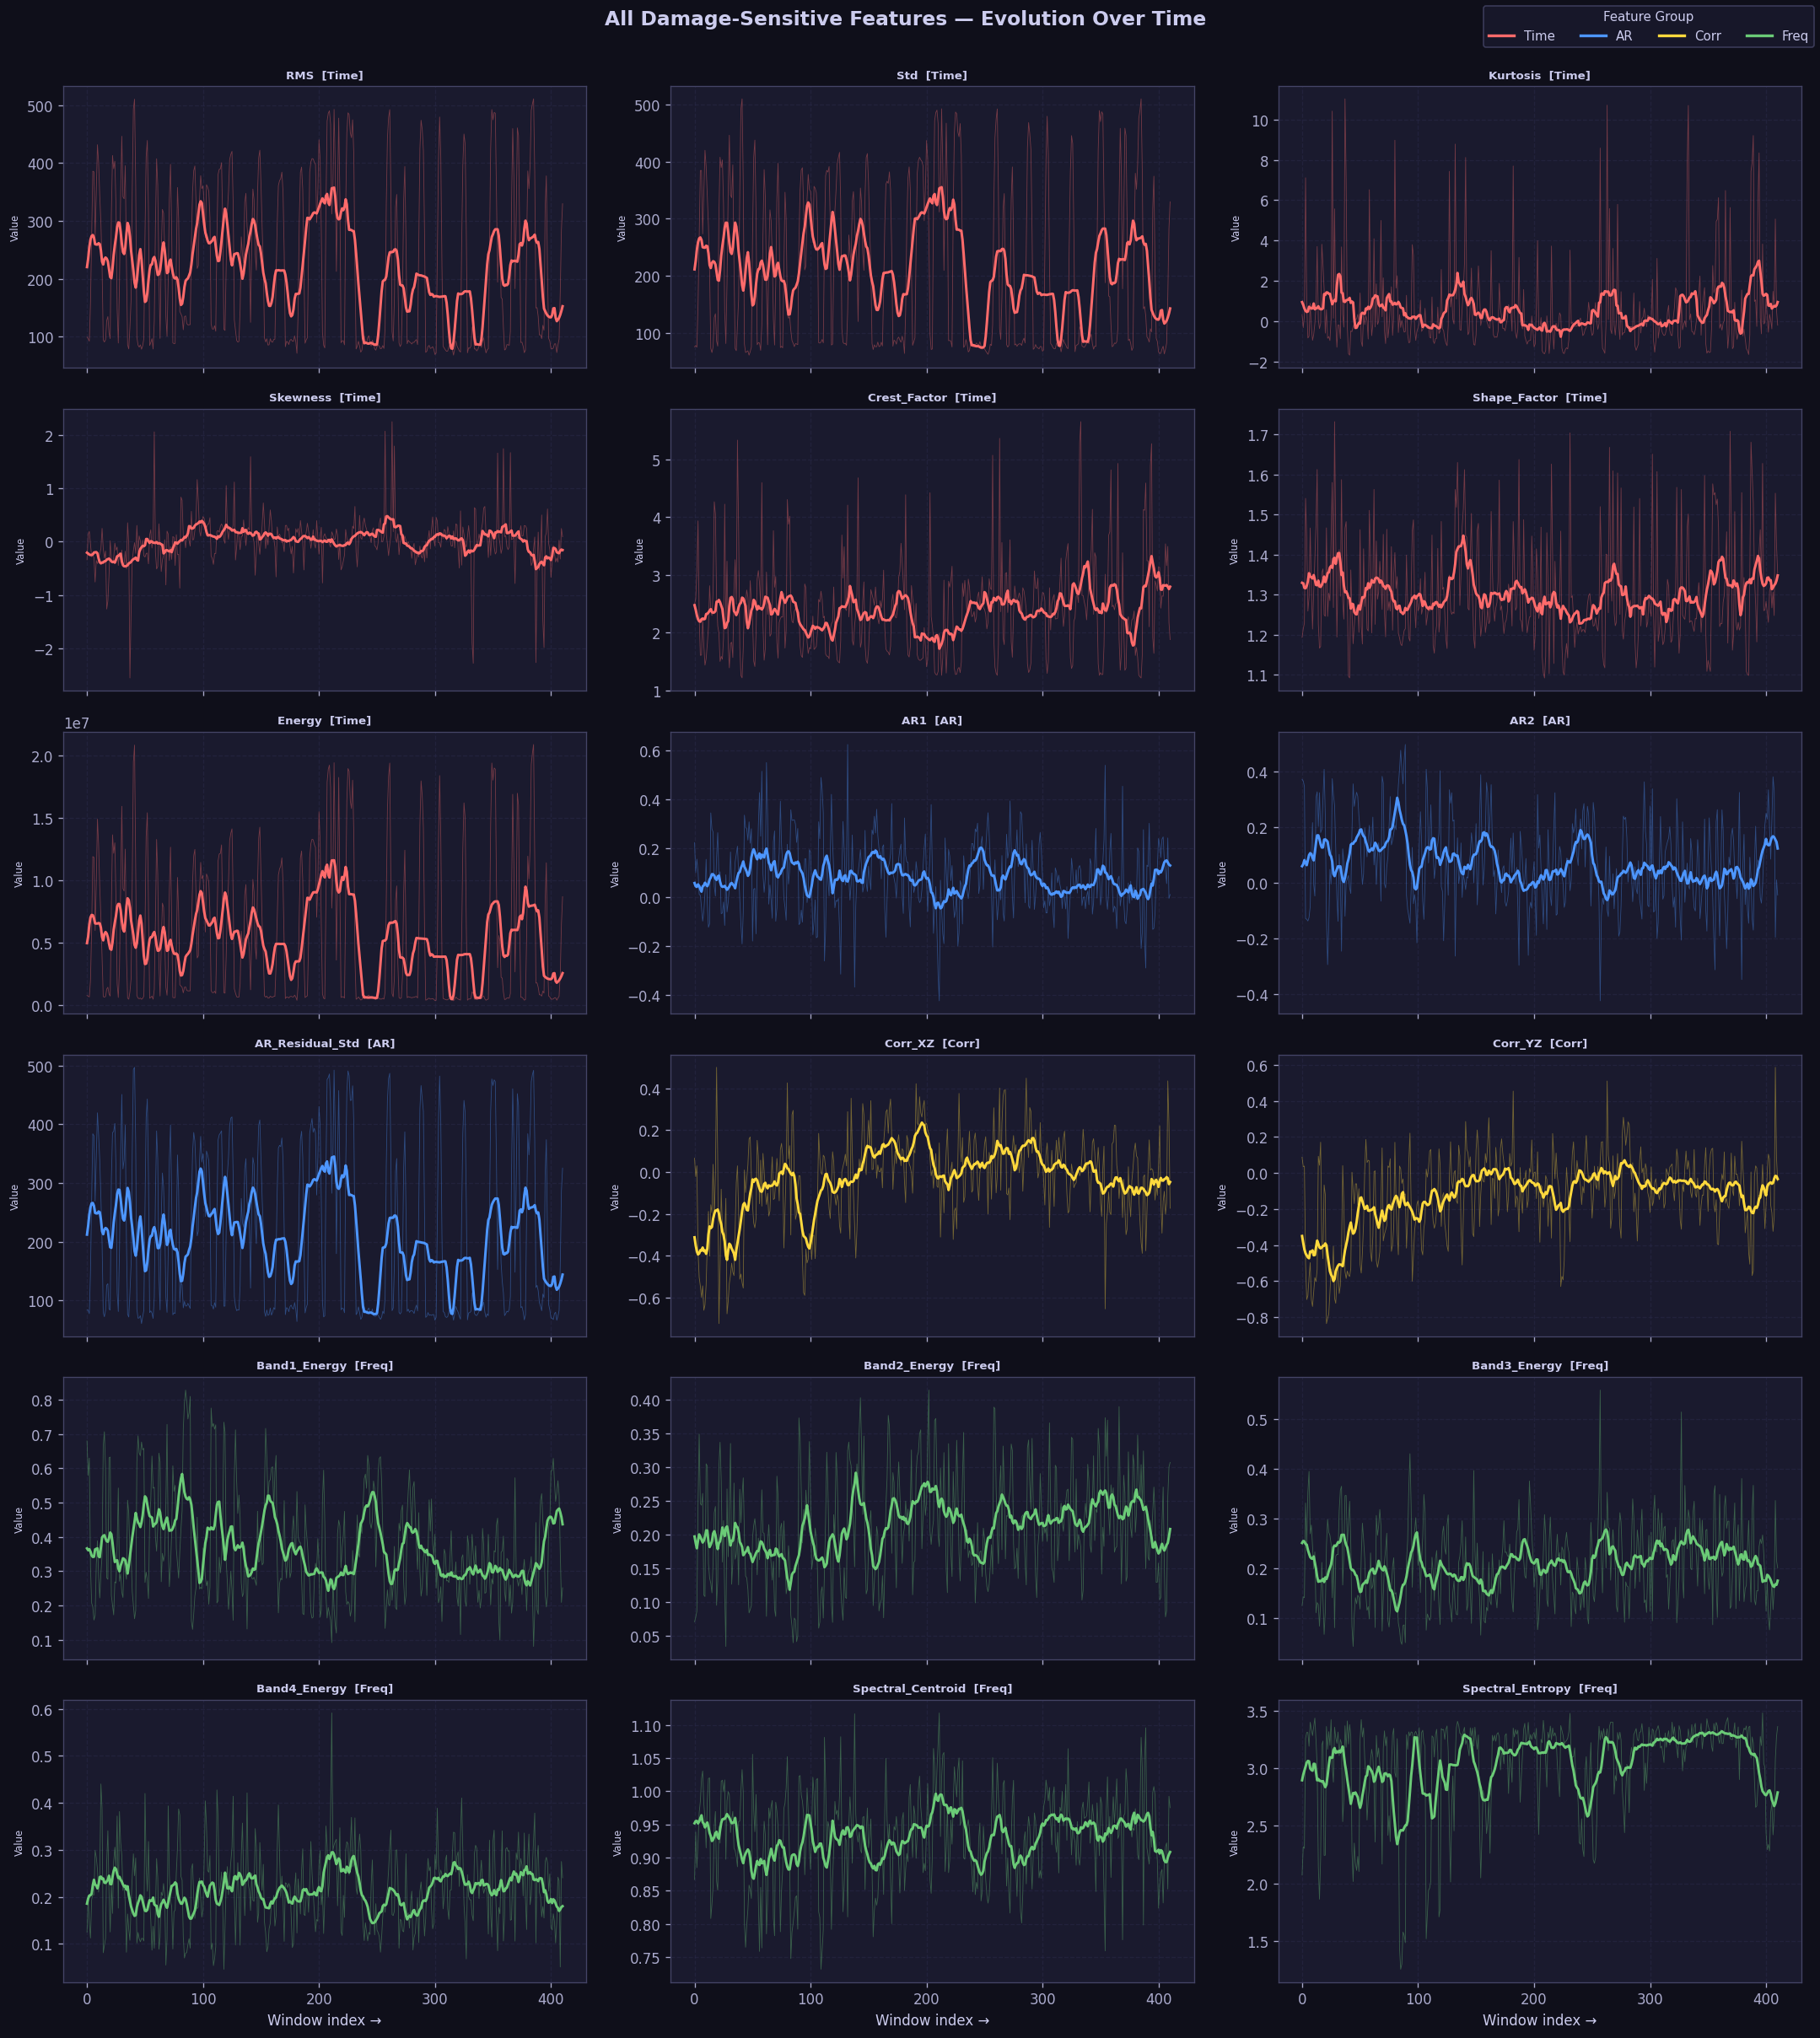

In [3]:
# ── All 18 features plotted vs window index ────────────────────────────────────
fig, axes = plt.subplots(6, 3, figsize=(18, 20), sharex=True)
fig.suptitle('All Damage-Sensitive Features — Evolution Over Time', fontsize=14, fontweight='bold', y=1.005)

for ax, feat in zip(axes.flatten(), ALL_FEATS):
    group = FEAT_GROUP[feat]
    color = GROUP_COLORS[group]
    y = df[feat]
    smooth = y.rolling(15, center=True, min_periods=1).mean()
    ax.plot(df['time_idx'], y,      color=color, lw=0.5, alpha=0.4)
    ax.plot(df['time_idx'], smooth, color=color, lw=1.8, label='Trend')
    ax.set_title(f'{feat}  [{group}]', fontsize=8, fontweight='bold')
    ax.set_ylabel('Value', fontsize=7)
    ax.grid(True)

axes[-1][0].set_xlabel('Window index →')
axes[-1][1].set_xlabel('Window index →')
axes[-1][2].set_xlabel('Window index →')

# Legend for groups
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color=c, lw=2, label=g) for g, c in GROUP_COLORS.items()]
fig.legend(handles=handles, loc='upper right', ncol=4, fontsize=9,
           title='Feature Group', title_fontsize=9)

plt.tight_layout()
plt.savefig('01_feature_evolution.png', bbox_inches='tight', dpi=130)
plt.show()

## 4. Distribution Analysis

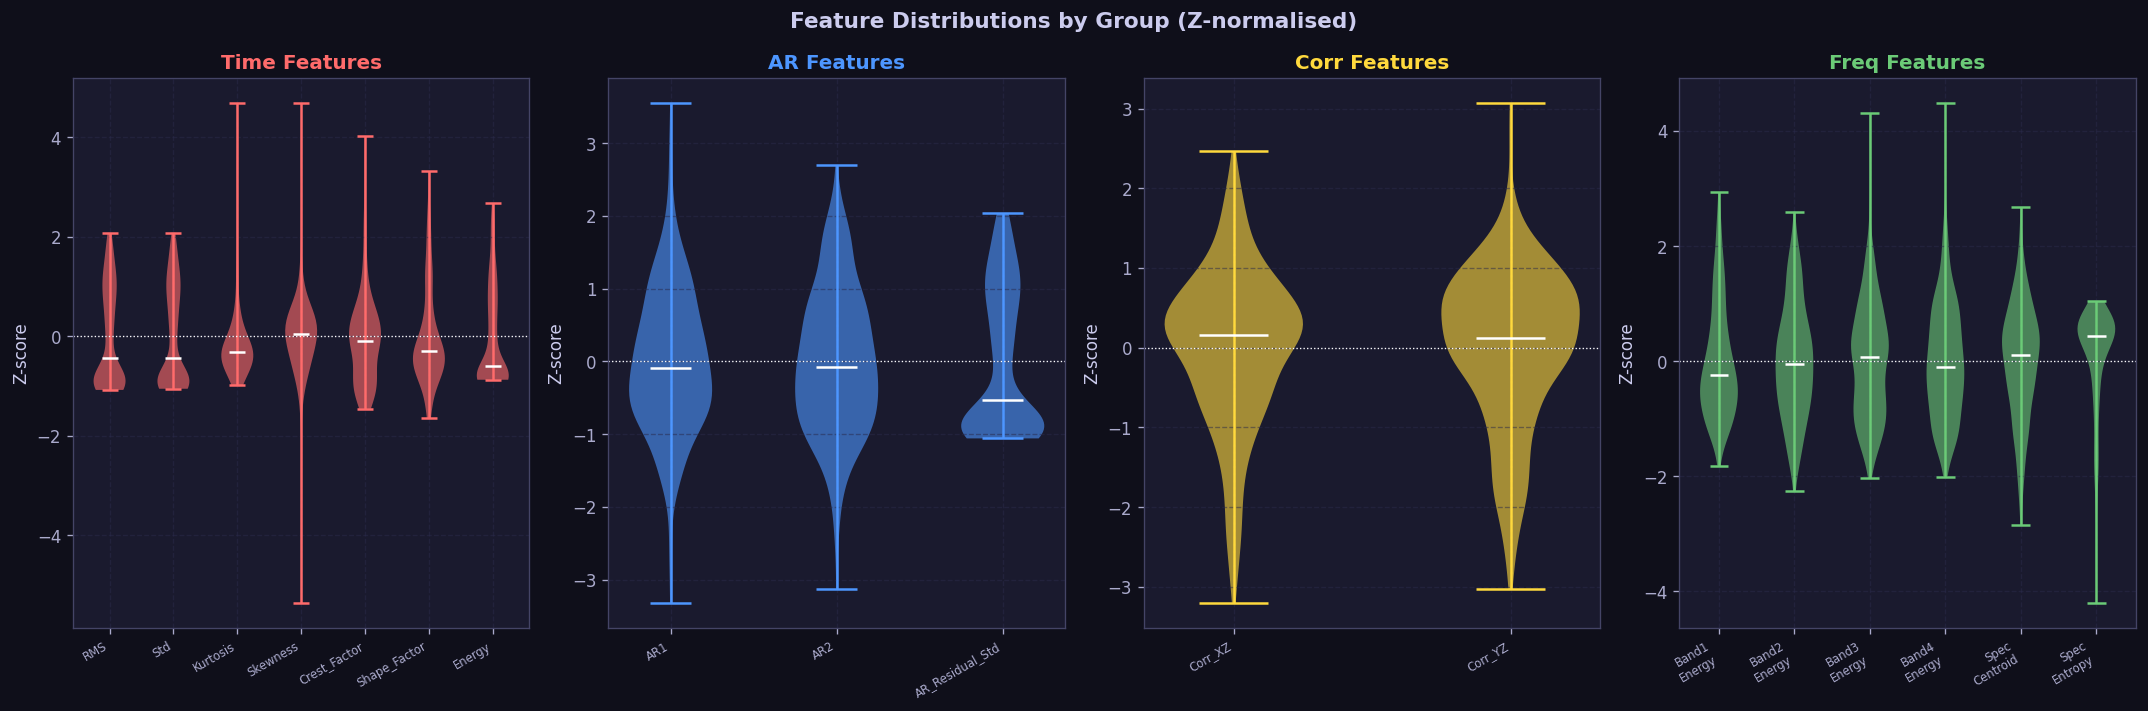

In [4]:
# ── Violin plots grouped by feature family ────────────────────────────────────
scaler_viz = StandardScaler()
df_scaled_viz = pd.DataFrame(
    scaler_viz.fit_transform(df[ALL_FEATS]),
    columns=ALL_FEATS
)

df_melt = df_scaled_viz.melt(var_name='Feature', value_name='Z-score')
df_melt['Group'] = df_melt['Feature'].map(FEAT_GROUP)

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle('Feature Distributions by Group (Z-normalised)', fontsize=13, fontweight='bold')

for ax, (group, color) in zip(axes, GROUP_COLORS.items()):
    feats = [f for f in ALL_FEATS if FEAT_GROUP[f] == group]
    subset = df_scaled_viz[feats].melt(var_name='Feature', value_name='Value')
    vp = ax.violinplot([df_scaled_viz[f].values for f in feats],
                        positions=range(len(feats)), showmedians=True)
    for body in vp['bodies']:
        body.set_facecolor(color)
        body.set_alpha(0.6)
    vp['cmedians'].set_color('white')
    vp['cbars'].set_color(color)
    vp['cmins'].set_color(color)
    vp['cmaxes'].set_color(color)
    ax.set_xticks(range(len(feats)))
    ax.set_xticklabels([f.replace('_Energy','\nEnergy').replace('Spectral_','Spec\n')
                        for f in feats], fontsize=7, rotation=30, ha='right')
    ax.set_title(f'{group} Features', fontweight='bold', color=color)
    ax.set_ylabel('Z-score')
    ax.grid(True)
    ax.axhline(0, color='white', lw=0.8, linestyle=':')

plt.tight_layout()
plt.savefig('02_violin_distributions.png', bbox_inches='tight', dpi=130)
plt.show()

## 5. Correlation Analysis

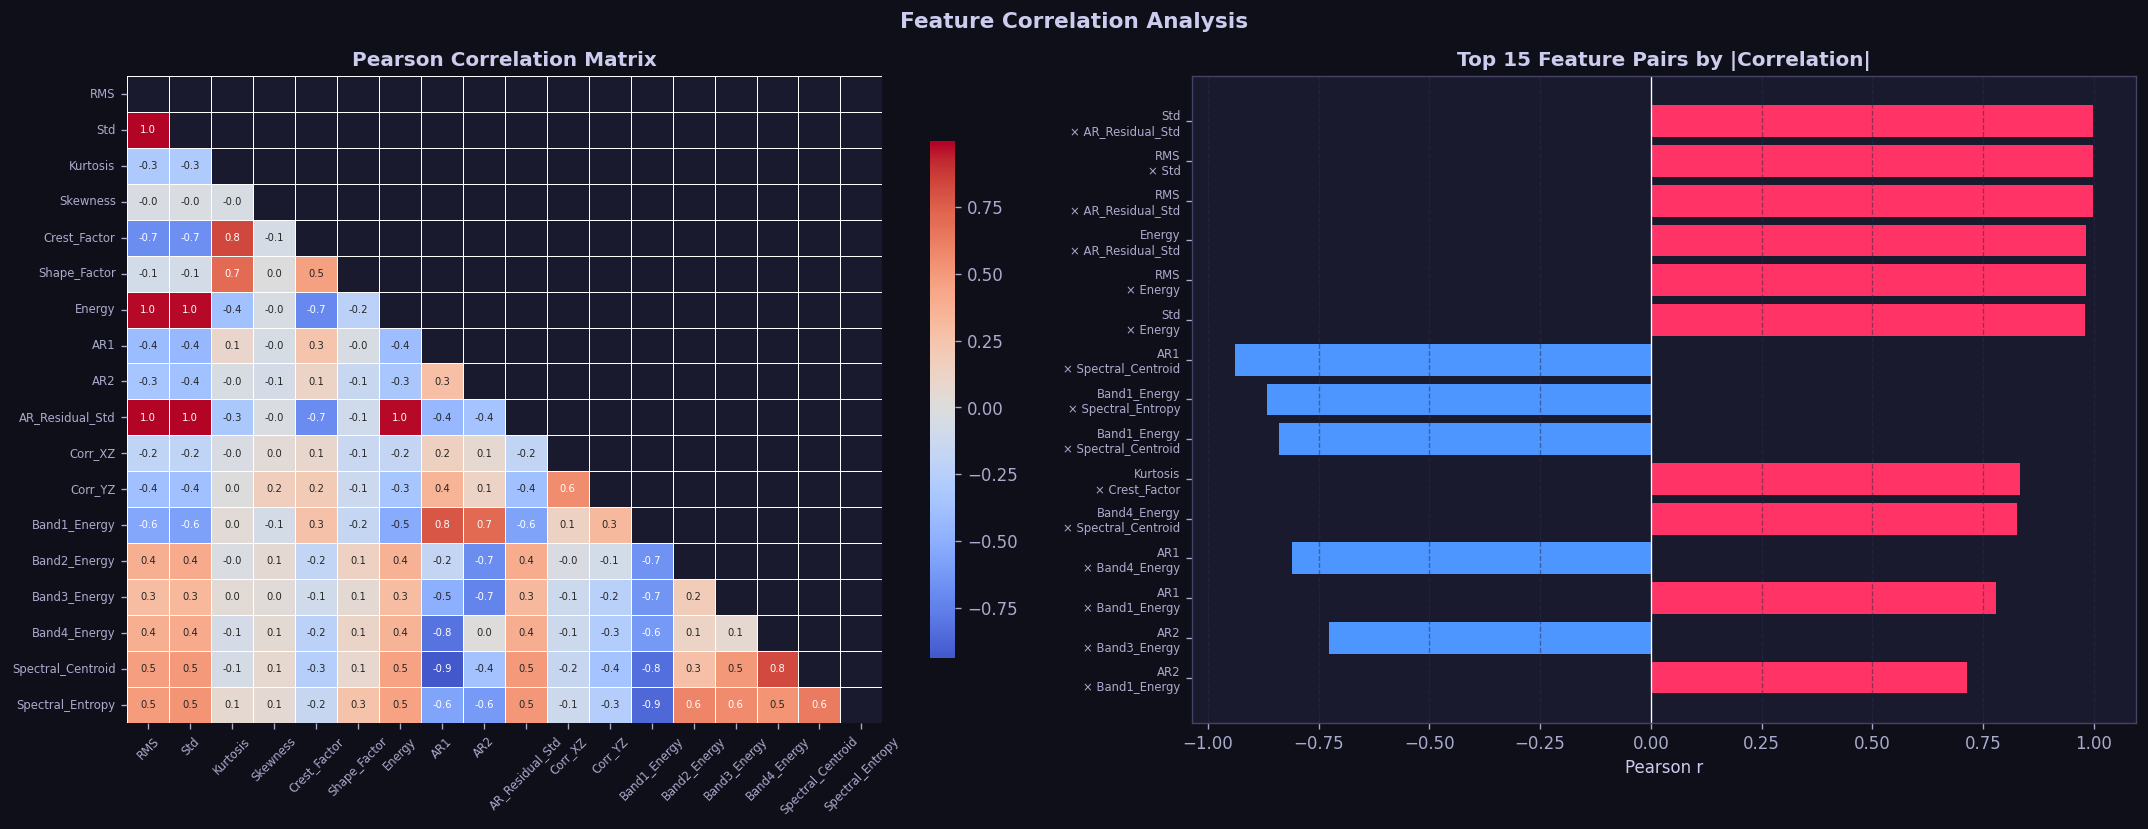

Most correlated pairs:
          F1                F2         r
         Std   AR_Residual_Std  0.998624
         RMS               Std  0.998552
         RMS   AR_Residual_Std  0.997987
      Energy   AR_Residual_Std  0.982869
         RMS            Energy  0.982289
         Std            Energy  0.981107
         AR1 Spectral_Centroid -0.938893
Band1_Energy  Spectral_Entropy -0.866103


In [5]:
# ── Full feature correlation heatmap ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Feature Correlation Analysis', fontsize=13, fontweight='bold')

corr = df[ALL_FEATS].corr()

# Pearson heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], annot=True, fmt='.1f', cmap='coolwarm',
            center=0, mask=mask, linewidths=0.3,
            annot_kws={'size': 6}, cbar_kws={'shrink': 0.8})
axes[0].set_title('Pearson Correlation Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

# Top correlated pairs
corr_pairs = []
for i, f1 in enumerate(ALL_FEATS):
    for j, f2 in enumerate(ALL_FEATS):
        if i < j:
            corr_pairs.append({'F1': f1, 'F2': f2, 'r': corr.loc[f1, f2]})
cp = pd.DataFrame(corr_pairs).sort_values('r', key=abs, ascending=False).head(15)
cp['pair'] = cp['F1'] + '\n× ' + cp['F2']
colors_bar = ['#ff3366' if r > 0 else '#4d96ff' for r in cp['r']]
axes[1].barh(cp['pair'][::-1], cp['r'][::-1], color=colors_bar[::-1], edgecolor='none')
axes[1].axvline(0, color='white', lw=0.8)
axes[1].set_xlabel('Pearson r')
axes[1].set_title('Top 15 Feature Pairs by |Correlation|', fontweight='bold')
axes[1].grid(True, axis='x')
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('03_correlation.png', bbox_inches='tight', dpi=130)
plt.show()

print('Most correlated pairs:')
print(cp[['F1','F2','r']].head(8).to_string(index=False))

## 6. PCA — Dimensionality Reduction

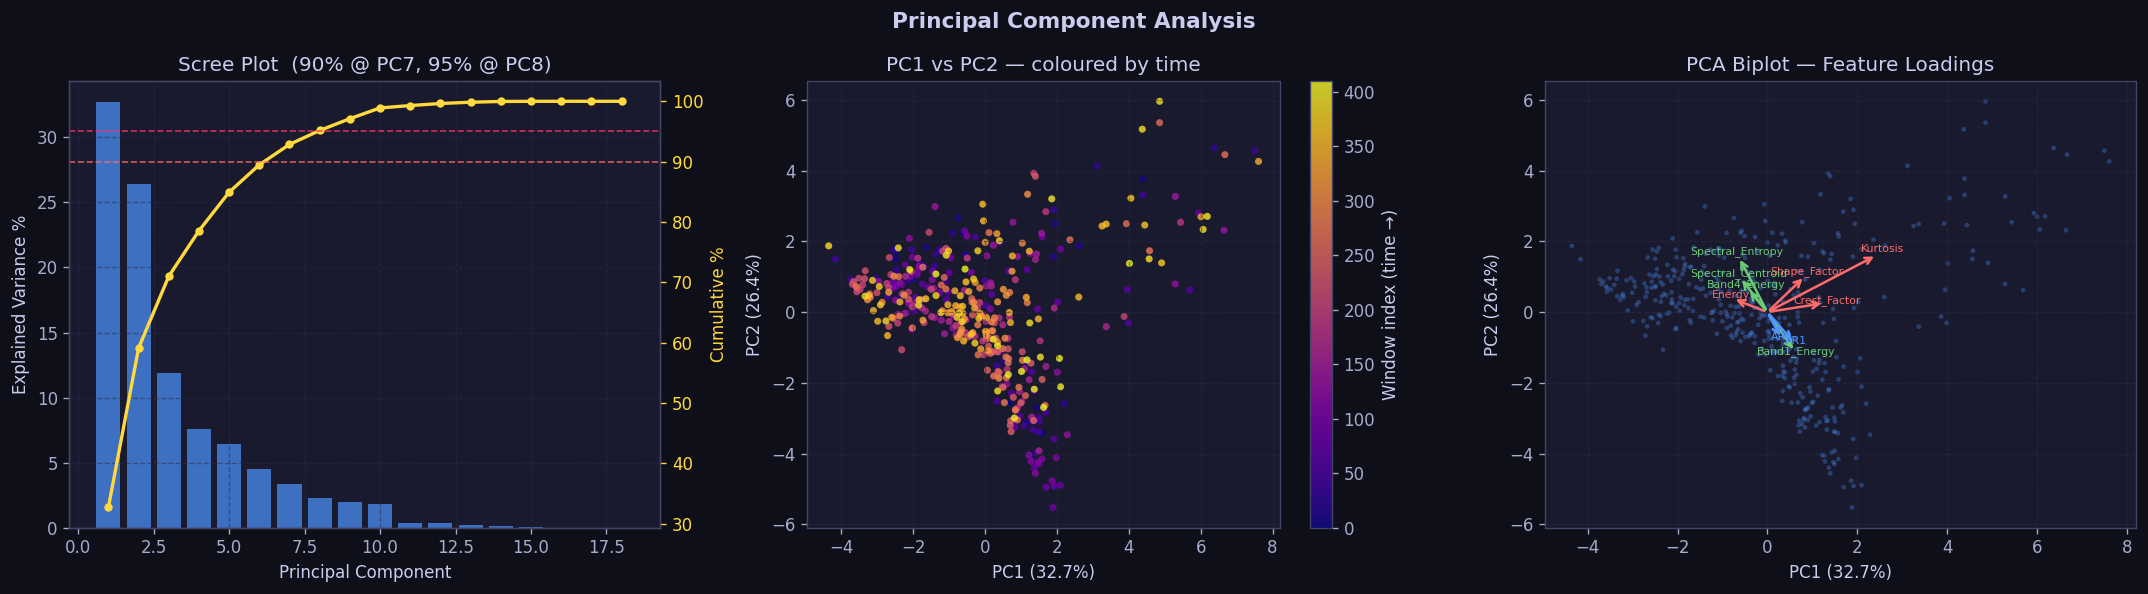

PCs needed for 90% variance: 7  |  95%: 8

Top loading features (PC1+PC2 magnitude):
                     PC1    PC2  magnitude
Kurtosis           0.698  0.462      0.837
Spectral_Entropy  -0.183  0.447      0.483
Shape_Factor       0.240  0.291      0.377
Crest_Factor       0.364  0.073      0.372
Band1_Energy       0.177 -0.323      0.368
Spectral_Centroid -0.175  0.281      0.331
AR1                0.170 -0.249      0.302
Energy            -0.221  0.109      0.246
AR2                0.090 -0.216      0.234
Band4_Energy      -0.126  0.190      0.228


In [6]:
scaler = RobustScaler()   # robust to outliers (better for damage data)
X = scaler.fit_transform(df[ALL_FEATS])

pca = PCA(random_state=42)
X_pca = pca.fit_transform(X)
evr   = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

n_90 = np.argmax(cum_evr >= 0.90) + 1
n_95 = np.argmax(cum_evr >= 0.95) + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Principal Component Analysis', fontsize=13, fontweight='bold')

# Scree plot
axes[0].bar(range(1, len(evr)+1), evr*100, color='#4d96ff', alpha=0.7, label='Individual')
ax2 = axes[0].twinx()
ax2.plot(range(1, len(evr)+1), cum_evr*100, 'o-', color='#ffd93d', lw=2, ms=4, label='Cumulative')
ax2.axhline(90, color='#ff6b6b', lw=1, linestyle='--', alpha=0.8)
ax2.axhline(95, color='#ff3366', lw=1, linestyle='--', alpha=0.8)
ax2.set_ylabel('Cumulative %', color='#ffd93d')
ax2.tick_params(axis='y', colors='#ffd93d')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance %')
axes[0].set_title(f'Scree Plot  (90% @ PC{n_90}, 95% @ PC{n_95})')
axes[0].grid(True)

# PC1 vs PC2 coloured by time
sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=df['time_idx'], cmap='plasma', s=18, alpha=0.8, edgecolors='none')
plt.colorbar(sc, ax=axes[1], label='Window index (time →)')
axes[1].set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
axes[1].set_title('PC1 vs PC2 — coloured by time')
axes[1].grid(True)

# Loadings biplot (top 8 features by loading magnitude)
loadings = pd.DataFrame(pca.components_[:2].T, index=ALL_FEATS,
                         columns=['PC1', 'PC2'])
loadings['magnitude'] = np.sqrt(loadings['PC1']**2 + loadings['PC2']**2)
top_load = loadings.nlargest(10, 'magnitude')

axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c='#4d96ff', s=8, alpha=0.3, edgecolors='none')
scale = 3.5
for feat, row in top_load.iterrows():
    group = FEAT_GROUP[feat]
    color = GROUP_COLORS[group]
    axes[2].annotate('', xy=(row['PC1']*scale, row['PC2']*scale), xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    axes[2].text(row['PC1']*scale*1.05, row['PC2']*scale*1.05,
                 feat, fontsize=6.5, color=color, ha='center')

axes[2].set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
axes[2].set_title('PCA Biplot — Feature Loadings')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('04_pca.png', bbox_inches='tight', dpi=130)
plt.show()
print(f'PCs needed for 90% variance: {n_90}  |  95%: {n_95}')
print('\nTop loading features (PC1+PC2 magnitude):')
print(top_load[['PC1','PC2','magnitude']].round(3).to_string())

## 7. t-SNE — Non-linear Embedding

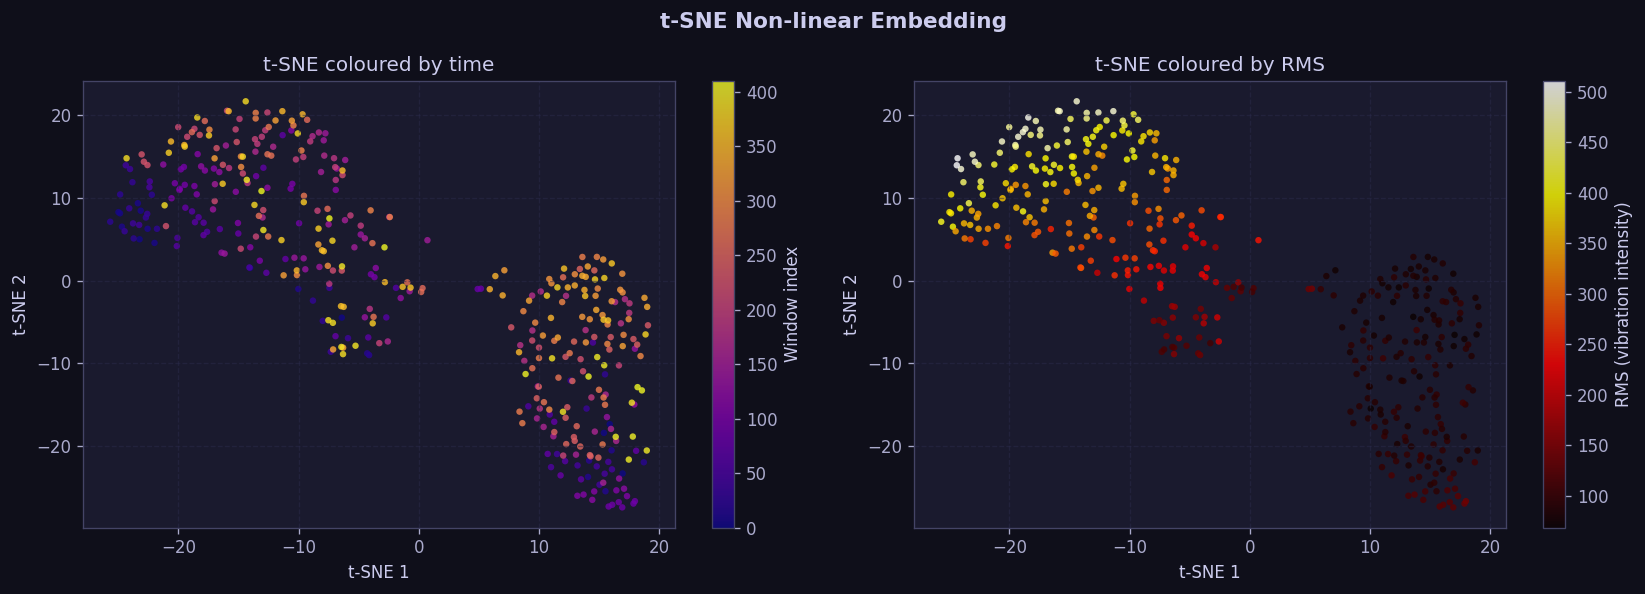

In [7]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('t-SNE Non-linear Embedding', fontsize=13, fontweight='bold')

# Coloured by time
sc1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=df['time_idx'], cmap='plasma', s=15, alpha=0.8, edgecolors='none')
plt.colorbar(sc1, ax=axes[0], label='Window index')
axes[0].set_title('t-SNE coloured by time')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].grid(True)

# Coloured by RMS (load proxy)
sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=df['RMS'], cmap='hot', s=15, alpha=0.8, edgecolors='none')
plt.colorbar(sc2, ax=axes[1], label='RMS (vibration intensity)')
axes[1].set_title('t-SNE coloured by RMS')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('05_tsne.png', bbox_inches='tight', dpi=130)
plt.show()

## 8. Clustering — Finding Bridge States

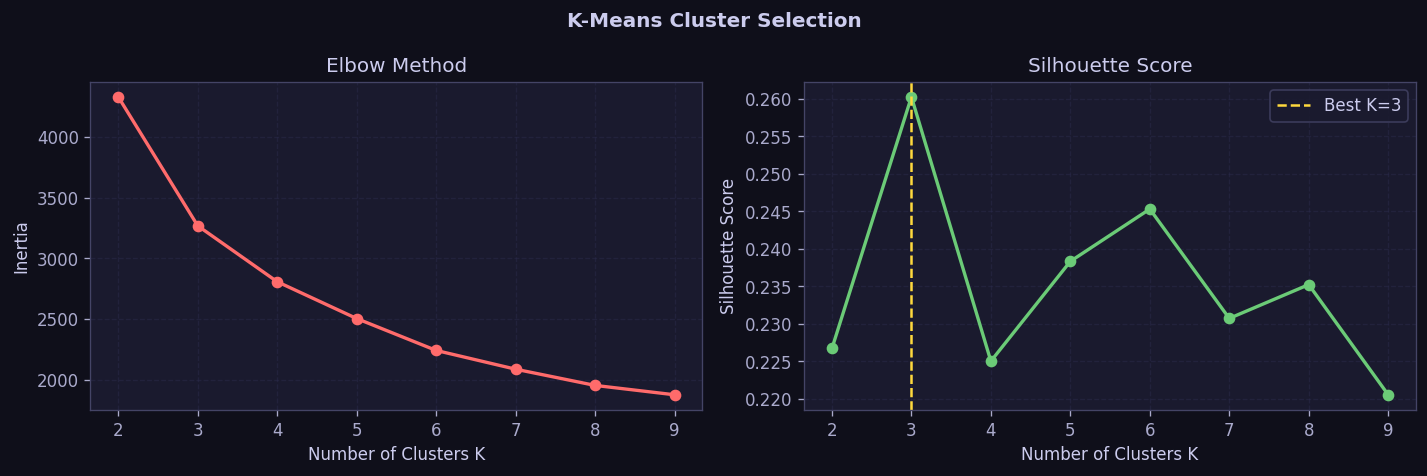

Best K = 3  (silhouette = 0.260)


In [8]:
# ── 8A: Optimal K via Elbow + Silhouette ─────────────────────────────────────
inertia, sil_scores = [], []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X, km.labels_))

best_k = K_range[np.argmax(sil_scores)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('K-Means Cluster Selection', fontsize=12, fontweight='bold')

axes[0].plot(K_range, inertia, 'o-', color='#ff6b6b', lw=2, ms=6)
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True)

axes[1].plot(K_range, sil_scores, 'o-', color='#6bcb77', lw=2, ms=6)
axes[1].axvline(best_k, color='#ffd93d', lw=1.5, linestyle='--', label=f'Best K={best_k}')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('06_cluster_selection.png', bbox_inches='tight', dpi=130)
plt.show()
print(f'Best K = {best_k}  (silhouette = {max(sil_scores):.3f})')

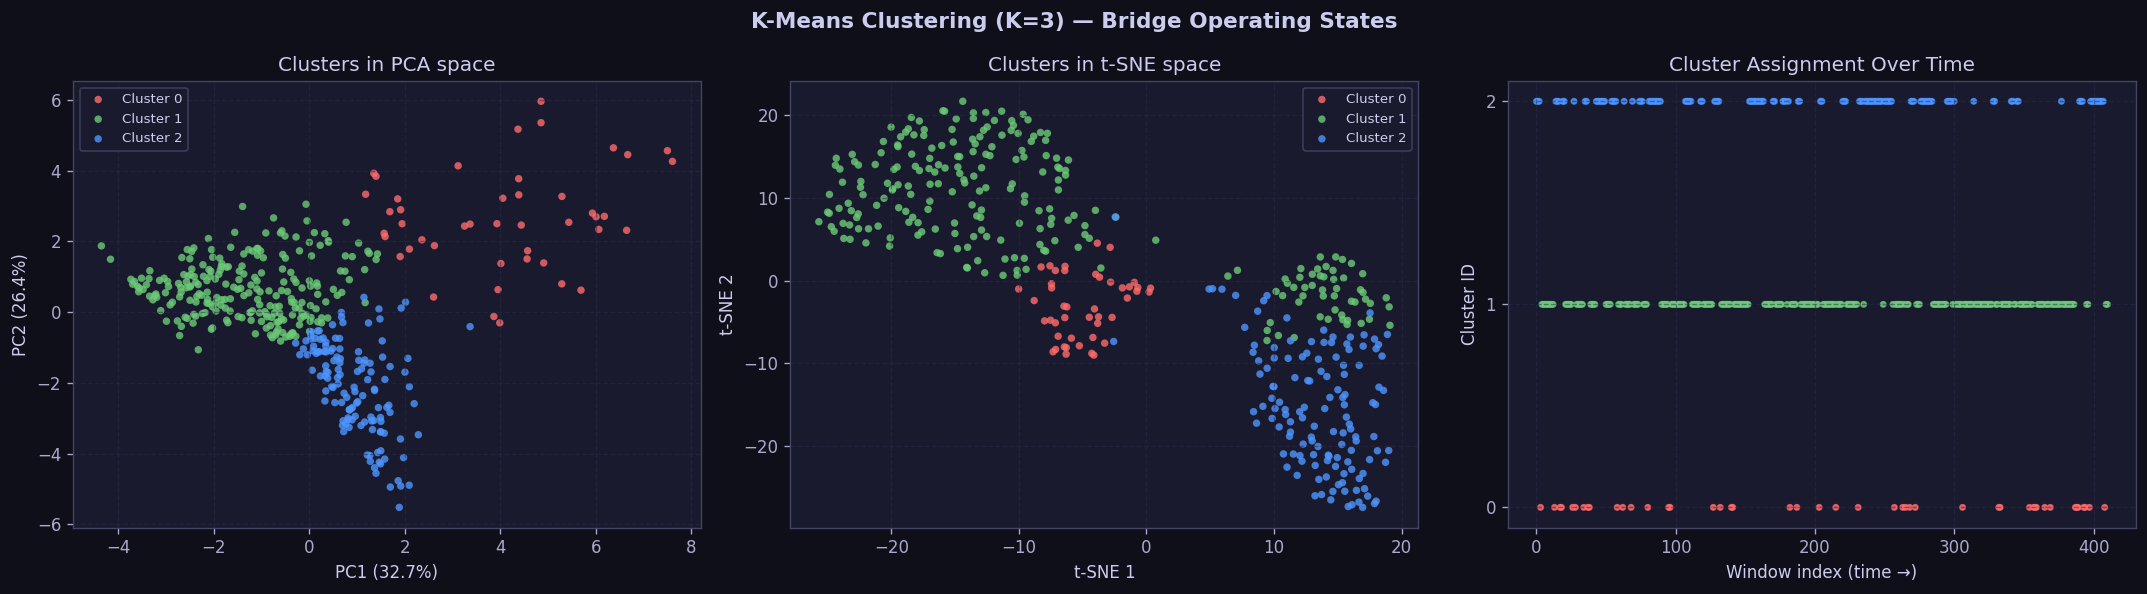

Cluster sizes:
cluster
0     45
1    235
2    131


In [9]:
# ── 8B: K-Means with best K ───────────────────────────────────────────────────
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = km_best.fit_predict(X)

CLUSTER_COLORS = ['#ff6b6b','#6bcb77','#4d96ff','#ffd93d','#c77dff','#ff9f1c','#00d4ff','#ff3366']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'K-Means Clustering (K={best_k}) — Bridge Operating States', fontsize=13, fontweight='bold')

# PCA 2D with clusters
for k in range(best_k):
    mask = df['cluster'] == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=CLUSTER_COLORS[k], s=20, alpha=0.8, label=f'Cluster {k}', edgecolors='none')
axes[0].set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
axes[0].set_title('Clusters in PCA space')
axes[0].legend(fontsize=8)
axes[0].grid(True)

# t-SNE with clusters
for k in range(best_k):
    mask = df['cluster'] == k
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    color=CLUSTER_COLORS[k], s=20, alpha=0.8, label=f'Cluster {k}', edgecolors='none')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('Clusters in t-SNE space')
axes[1].legend(fontsize=8)
axes[1].grid(True)

# Cluster over time
axes[2].scatter(df['time_idx'], df['cluster'],
                c=[CLUSTER_COLORS[k] for k in df['cluster']], s=10, alpha=0.8)
axes[2].set_xlabel('Window index (time →)')
axes[2].set_ylabel('Cluster ID')
axes[2].set_title('Cluster Assignment Over Time')
axes[2].set_yticks(range(best_k))
axes[2].grid(True)

plt.tight_layout()
plt.savefig('07_clustering.png', bbox_inches='tight', dpi=130)
plt.show()

print('Cluster sizes:')
print(df['cluster'].value_counts().sort_index().to_string())

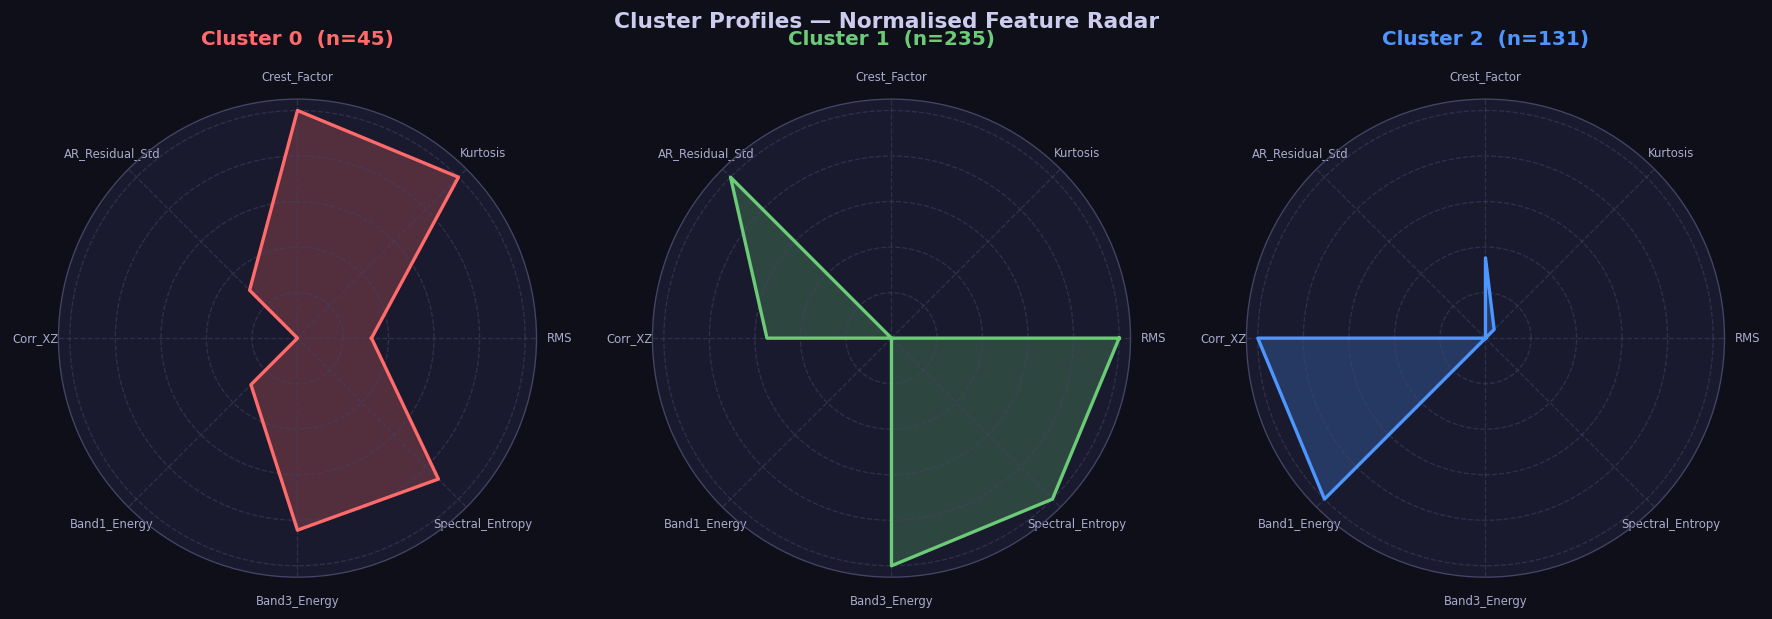

In [26]:
# ── 8C: Cluster profiles — radar/spider chart ─────────────────────────────────
# Key features to profile (one per group)
PROFILE_FEATS = ['RMS','Kurtosis','Crest_Factor','AR_Residual_Std',
                 'Corr_XZ','Band1_Energy','Band3_Energy','Spectral_Entropy']

# Normalise cluster means to [0,1]
cluster_means = df.groupby('cluster')[PROFILE_FEATS].mean()
cluster_norm  = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min() + 1e-9)

N = len(PROFILE_FEATS)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, best_k, figsize=(5*best_k, 5), subplot_kw={'polar': True})
if best_k == 1: axes = [axes]
fig.suptitle('Cluster Profiles — Normalised Feature Radar', fontsize=13, fontweight='bold')

for k, ax in enumerate(axes):
    values = cluster_norm.loc[k].tolist()
    values += values[:1]
    color  = CLUSTER_COLORS[k]
    ax.plot(angles, values, color=color, lw=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(PROFILE_FEATS, size=7)
    ax.set_yticklabels([])
    ax.set_title(f'Cluster {k}  (n={int((df["cluster"]==k).sum())})',
                 color=color, fontweight='bold', pad=15)
    ax.set_facecolor('#1a1a2e')
    ax.grid(color='#444466')

plt.tight_layout()
plt.savefig('08_cluster_radar.png', bbox_inches='tight', dpi=130)
plt.show()

## 9. Hierarchical Clustering Dendrogram

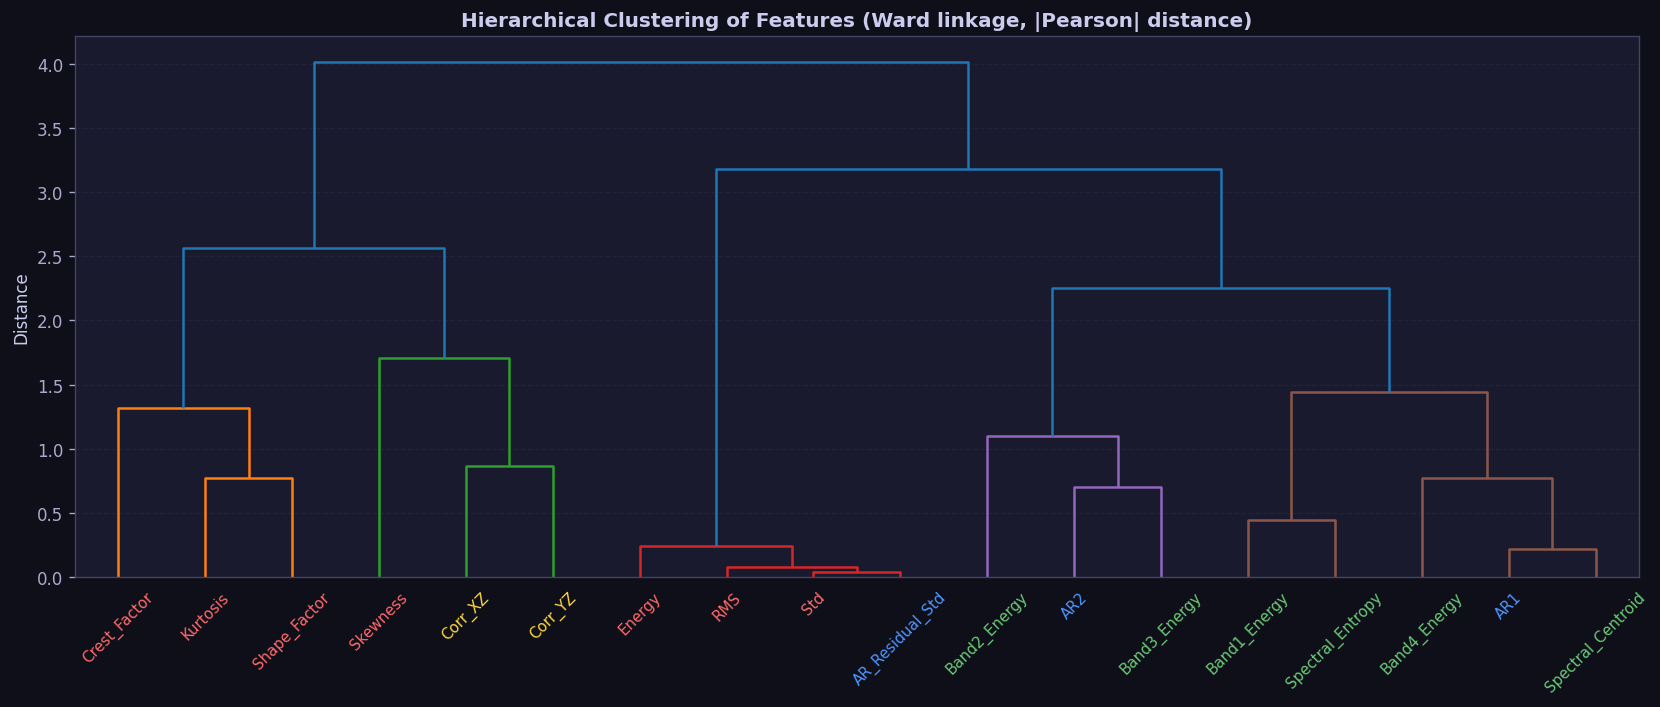

In [27]:
# Cluster features (not samples) to understand which features behave similarly
feat_corr_dist = 1 - np.abs(df[ALL_FEATS].corr())
linked = linkage(feat_corr_dist.values, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dend = dendrogram(linked, labels=ALL_FEATS, ax=ax,
                  leaf_rotation=45, leaf_font_size=9,
                  color_threshold=0.5*linked[:, 2].max())
ax.set_title('Hierarchical Clustering of Features (Ward linkage, |Pearson| distance)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Distance')
ax.grid(True, axis='y')

# Colour labels by group
for label in ax.get_xticklabels():
    feat = label.get_text()
    if feat in FEAT_GROUP:
        label.set_color(GROUP_COLORS[FEAT_GROUP[feat]])

plt.tight_layout()
plt.savefig('09_dendrogram.png', bbox_inches='tight', dpi=130)
plt.show()

## 10. Anomaly Detection

Isolation Forest anomalies : 21 (5.1%)
Z-score anomalies (>3σ)    : 38  (9.2%)


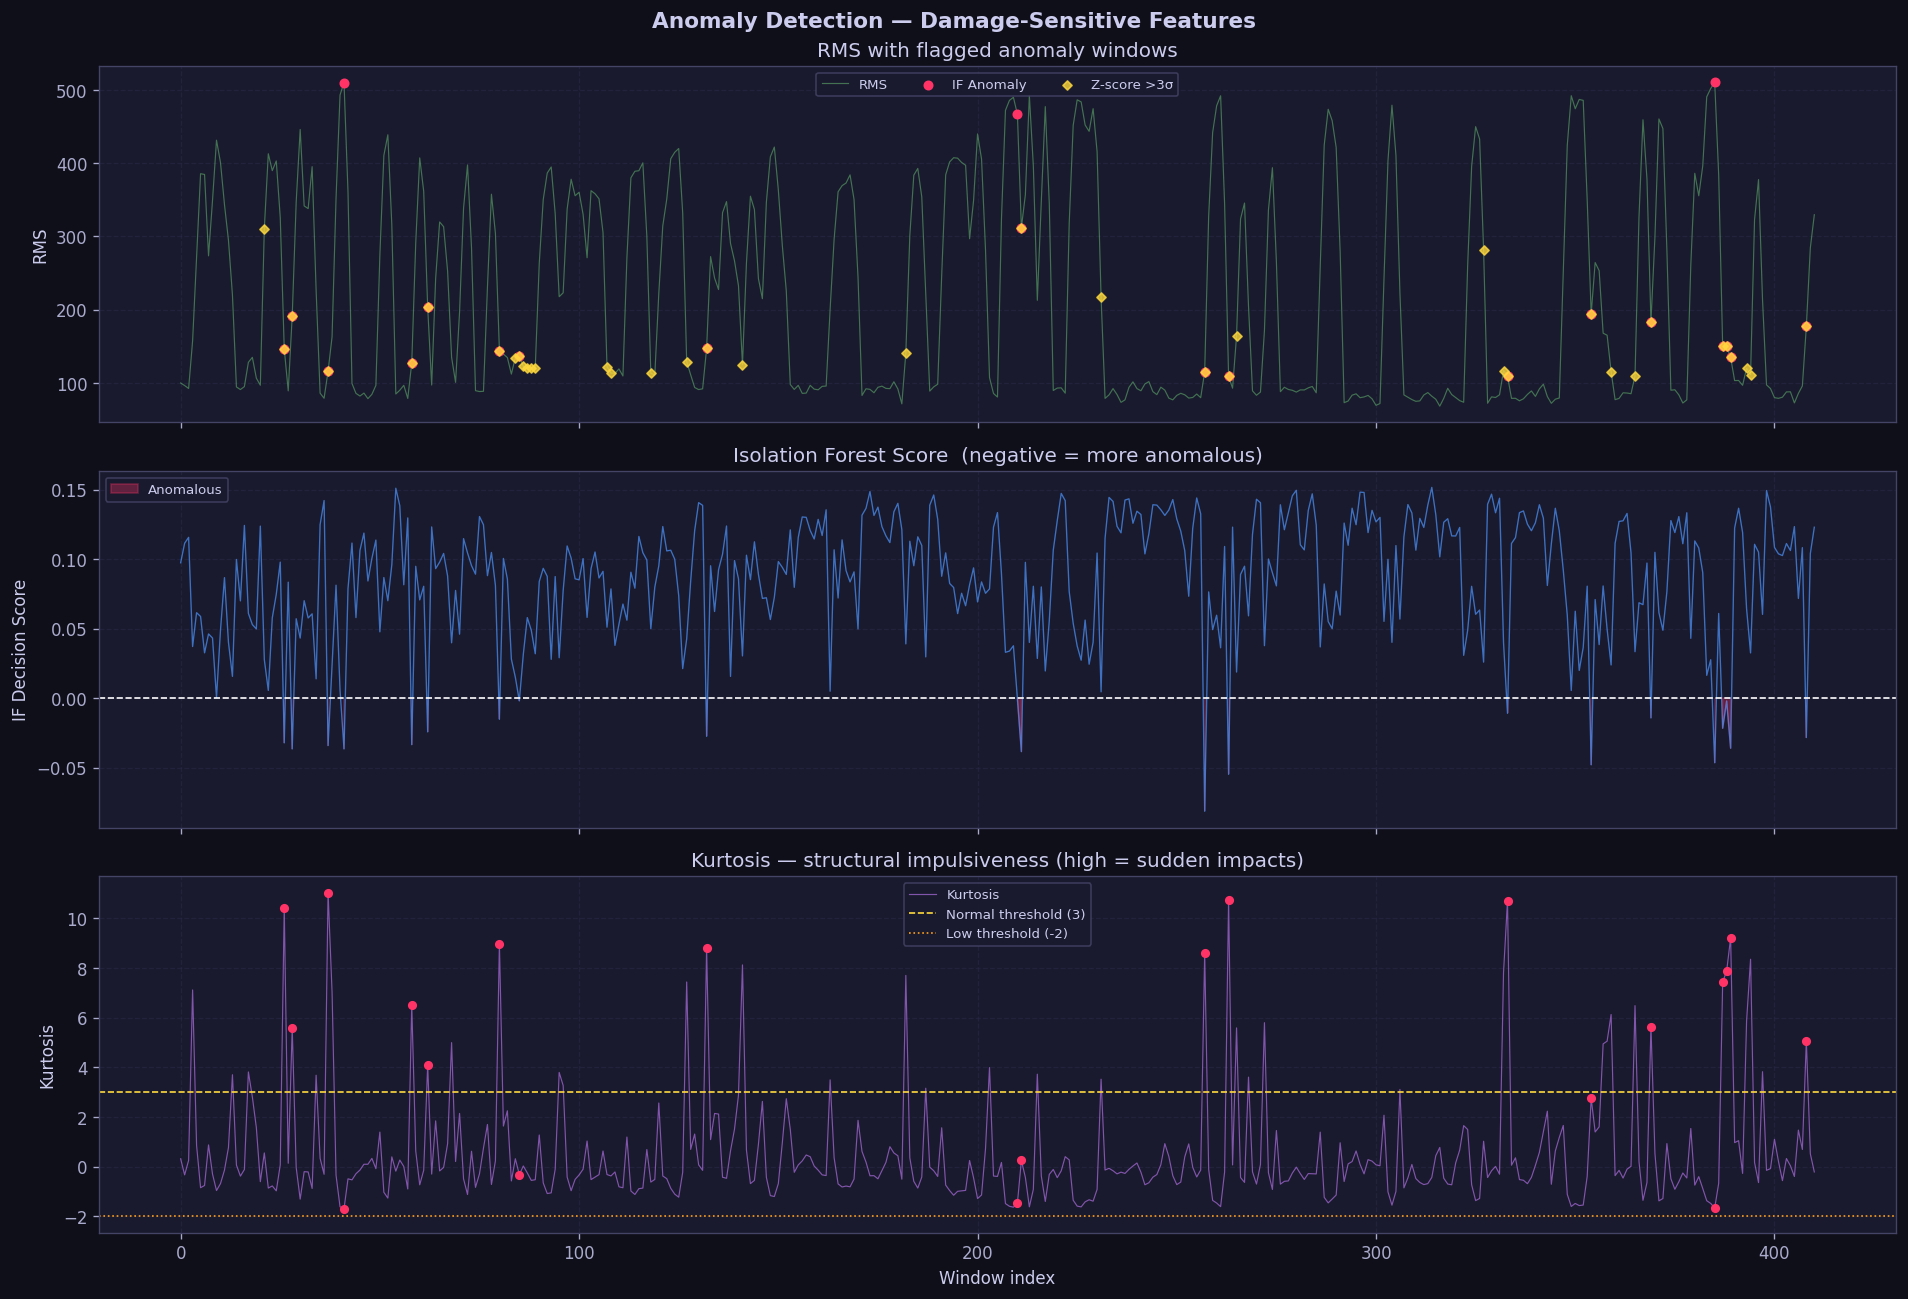

In [28]:
# ── Isolation Forest ──────────────────────────────────────────────────────────
iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=42)
iso.fit(X)
df['iso_label'] = np.where(iso.predict(X) == -1, 'Anomaly', 'Normal')
df['iso_score'] = iso.decision_function(X)

# ── Z-score multi-feature ─────────────────────────────────────────────────────
z = np.abs(zscore(df[ALL_FEATS]))
df['z_anomaly'] = (z > 3.0).any(axis=1)

n_iso = (df['iso_label']=='Anomaly').sum()
n_z   = df['z_anomaly'].sum()
print(f'Isolation Forest anomalies : {n_iso} ({n_iso/len(df)*100:.1f}%)')
print(f'Z-score anomalies (>3σ)    : {n_z}  ({n_z/len(df)*100:.1f}%)')

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
fig.suptitle('Anomaly Detection — Damage-Sensitive Features', fontsize=13, fontweight='bold')

t = df['time_idx']

# RMS anomalies
norm_m = df['iso_label'] == 'Normal'
anom_m = df['iso_label'] == 'Anomaly'
axes[0].plot(t, df['RMS'], color='#6bcb77', lw=0.7, alpha=0.5, label='RMS')
axes[0].scatter(t[anom_m], df.loc[anom_m,'RMS'], color='#ff3366', s=25, zorder=5, label='IF Anomaly')
axes[0].scatter(t[df['z_anomaly']], df.loc[df['z_anomaly'],'RMS'],
                color='#ffd93d', s=15, marker='D', zorder=6, label='Z-score >3σ', alpha=0.8)
axes[0].set_ylabel('RMS')
axes[0].legend(ncol=3, fontsize=8)
axes[0].grid(True)
axes[0].set_title('RMS with flagged anomaly windows')

# Isolation Forest score over time
axes[1].plot(t, df['iso_score'], color='#4d96ff', lw=0.8, alpha=0.7)
axes[1].fill_between(t, df['iso_score'], where=df['iso_score']<0,
                     color='#ff3366', alpha=0.3, label='Anomalous')
axes[1].axhline(0, color='white', lw=1, linestyle='--')
axes[1].set_ylabel('IF Decision Score')
axes[1].set_title('Isolation Forest Score  (negative = more anomalous)')
axes[1].legend(fontsize=8)
axes[1].grid(True)

# Kurtosis (impulsiveness indicator)
axes[2].plot(t, df['Kurtosis'], color='#c77dff', lw=0.7, alpha=0.6, label='Kurtosis')
axes[2].axhline(3,  color='#ffd93d', lw=1, linestyle='--', label='Normal threshold (3)')
axes[2].axhline(-2, color='#ff9f1c', lw=1, linestyle=':', label='Low threshold (-2)')
axes[2].scatter(t[anom_m], df.loc[anom_m,'Kurtosis'], color='#ff3366', s=20, zorder=5)
axes[2].set_xlabel('Window index')
axes[2].set_ylabel('Kurtosis')
axes[2].set_title('Kurtosis — structural impulsiveness (high = sudden impacts)')
axes[2].legend(fontsize=8)
axes[2].grid(True)

plt.tight_layout()
plt.savefig('10_anomaly_detection.png', bbox_inches='tight', dpi=130)
plt.show()

## 11. Structural Health Index (SHI)

Baseline SHI (first 10%): 36.1


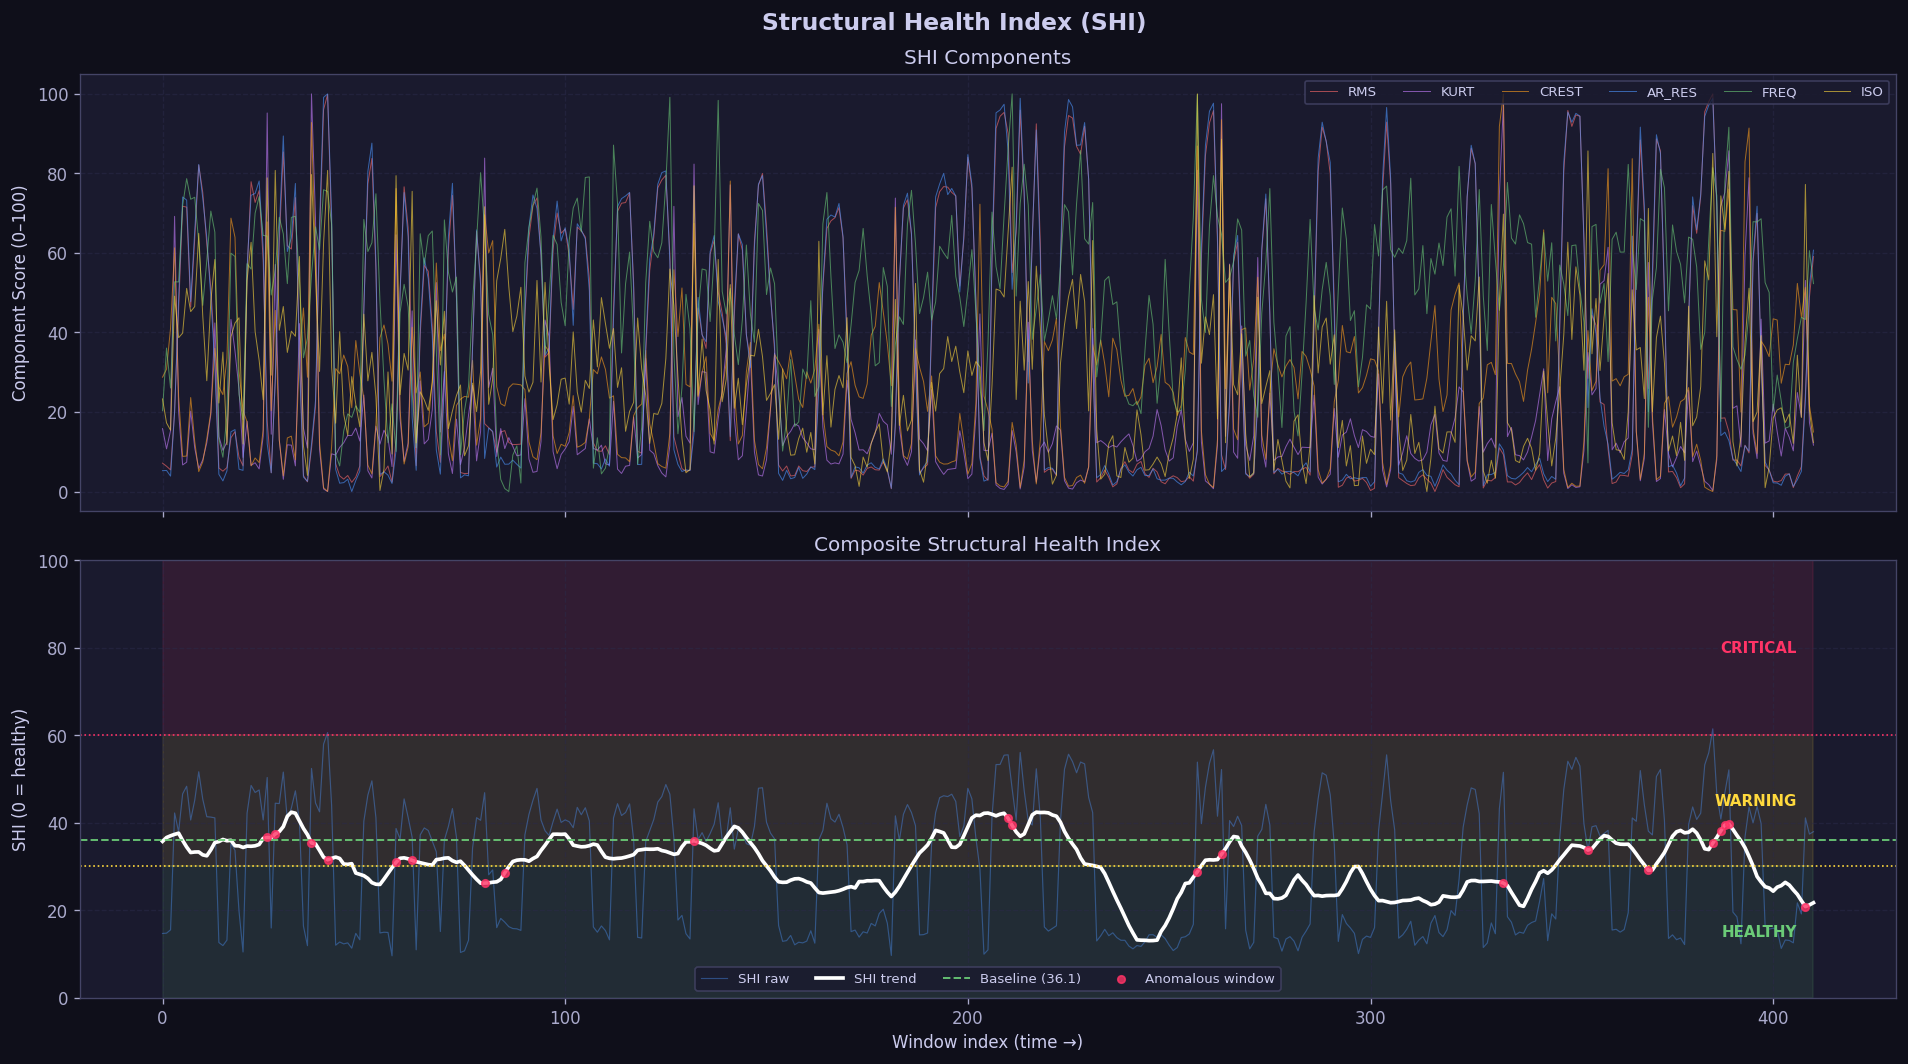

Mean SHI: 30.6  |  Peak SHI: 42.4  |  Zone: WARNING


In [29]:
def norm_0_100(s):
    r = s - s.min()
    return r / (r.max() + 1e-9) * 100

# SHI components — each scaled 0–100, higher = worse
df['shi_rms']     = norm_0_100(df['RMS'])
df['shi_kurt']    = norm_0_100(df['Kurtosis'].clip(-2, 15))  # high kurtosis = impulsive = bad
df['shi_crest']   = norm_0_100(df['Crest_Factor'])
df['shi_ar_res']  = norm_0_100(df['AR_Residual_Std'])        # high residual = process changed
df['shi_freq']    = norm_0_100(df['Band3_Energy'] + df['Band4_Energy'])  # high-freq energy
df['shi_iso']     = norm_0_100(-df['iso_score'])             # inverted: more anomalous = higher

W = {'shi_rms':0.25, 'shi_kurt':0.20, 'shi_crest':0.15,
     'shi_ar_res':0.20, 'shi_freq':0.10, 'shi_iso':0.10}
df['SHI'] = sum(df[k]*v for k, v in W.items())
df['SHI_smooth'] = df['SHI'].rolling(20, center=True, min_periods=1).mean()

# Baseline = first 10% of data
baseline_shi = df['SHI_smooth'].iloc[:int(len(df)*0.1)].mean()
print(f'Baseline SHI (first 10%): {baseline_shi:.1f}')

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Structural Health Index (SHI)', fontsize=14, fontweight='bold')

# Components
comp_colors = {'shi_rms':'#ff6b6b','shi_kurt':'#c77dff','shi_crest':'#ff9f1c',
               'shi_ar_res':'#4d96ff','shi_freq':'#6bcb77','shi_iso':'#ffd93d'}
for comp, color in comp_colors.items():
    axes[0].plot(t, df[comp], lw=0.6, alpha=0.6, color=color,
                 label=comp.replace('shi_','').upper())
axes[0].set_ylabel('Component Score (0–100)')
axes[0].legend(ncol=6, fontsize=8)
axes[0].grid(True)
axes[0].set_title('SHI Components')

# Composite SHI
axes[1].fill_between(t, 0,  30, alpha=0.10, color='#6bcb77')
axes[1].fill_between(t, 30, 60, alpha=0.10, color='#ffd93d')
axes[1].fill_between(t, 60, 100,alpha=0.10, color='#ff3366')
axes[1].plot(t, df['SHI'],        color='#4d96ff', lw=0.7, alpha=0.4, label='SHI raw')
axes[1].plot(t, df['SHI_smooth'], color='white',   lw=2.2,            label='SHI trend')
axes[1].axhline(baseline_shi, color='#6bcb77', lw=1.2, linestyle='--',
                alpha=0.9, label=f'Baseline ({baseline_shi:.1f})')
axes[1].axhline(30, color='#ffd93d', lw=1, linestyle=':')
axes[1].axhline(60, color='#ff3366', lw=1, linestyle=':')

# Annotate anomalies on SHI
axes[1].scatter(t[anom_m], df.loc[anom_m,'SHI_smooth'],
                color='#ff3366', s=20, zorder=5, label='Anomalous window', alpha=0.8)

for y, label, color in [(15,'HEALTHY','#6bcb77'),(45,'WARNING','#ffd93d'),(80,'CRITICAL','#ff3366')]:
    axes[1].text(t.iloc[-1]*0.99, y, label, ha='right', va='center',
                 color=color, fontsize=9, fontweight='bold')

axes[1].set_ylim(0, 100)
axes[1].set_xlabel('Window index (time →)')
axes[1].set_ylabel('SHI (0 = healthy)')
axes[1].set_title('Composite Structural Health Index')
axes[1].legend(ncol=4, fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.savefig('11_shi.png', bbox_inches='tight', dpi=130)
plt.show()

zone = 'HEALTHY' if df['SHI_smooth'].mean()<30 else ('WARNING' if df['SHI_smooth'].mean()<60 else 'CRITICAL')
print(f'Mean SHI: {df["SHI_smooth"].mean():.1f}  |  Peak SHI: {df["SHI_smooth"].max():.1f}  |  Zone: {zone}')

## 12. Feature Importance via Surrogate Model

GBM → SHI cross-validated R² = 0.960


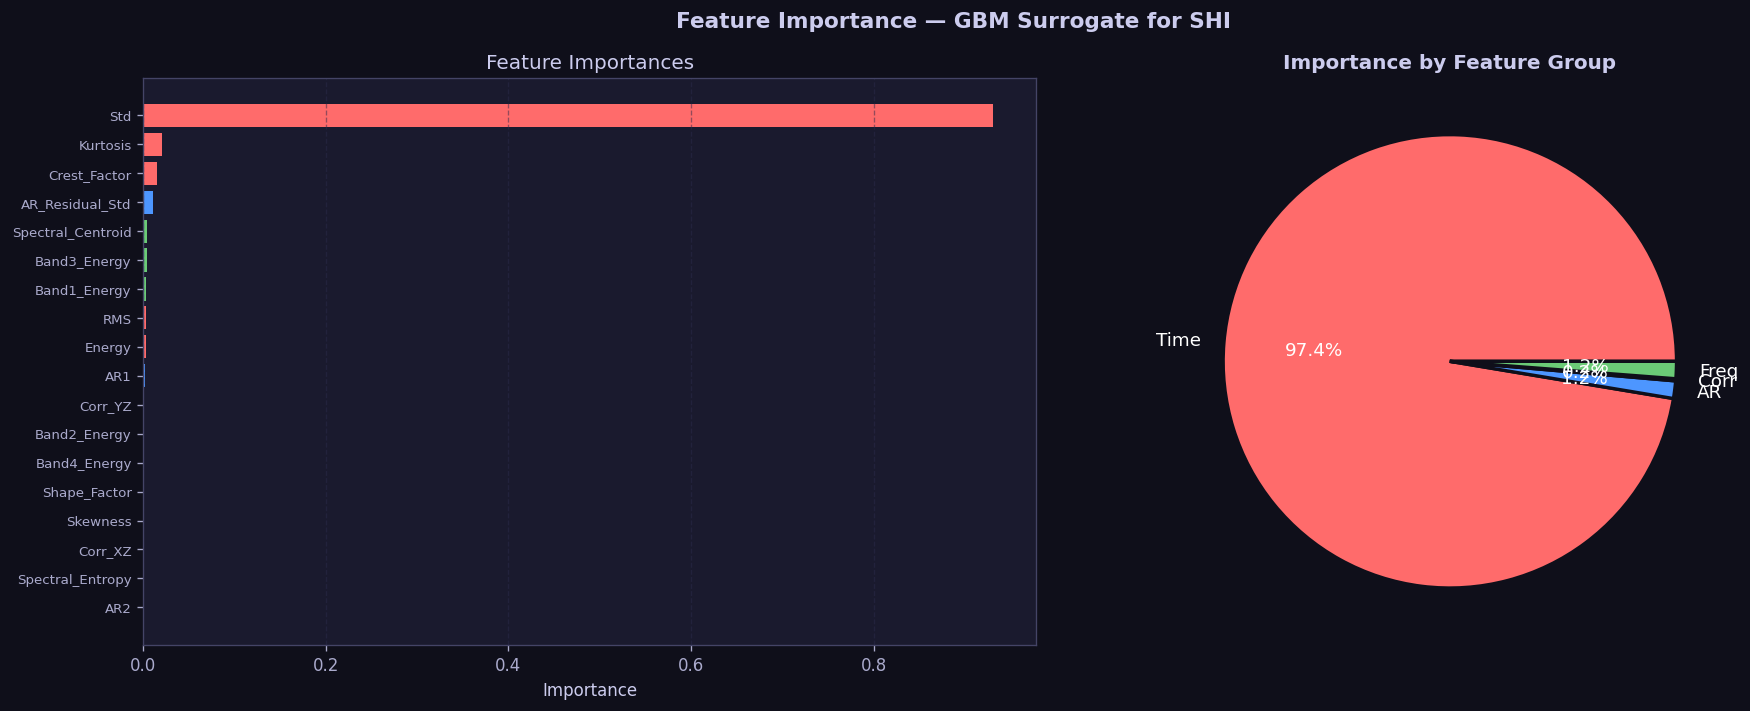

In [30]:
# Train a GBM to predict SHI from raw features — feature importances tell us
# which features drive structural health the most

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

gbm = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                 learning_rate=0.05, random_state=42)
gbm.fit(X, df['SHI'])

cv_r2 = cross_val_score(gbm, X, df['SHI'], cv=5, scoring='r2').mean()
print(f'GBM → SHI cross-validated R² = {cv_r2:.3f}')

imp = pd.Series(gbm.feature_importances_, index=ALL_FEATS).sort_values(ascending=True)
bar_colors = [GROUP_COLORS[FEAT_GROUP[f]] for f in imp.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance — GBM Surrogate for SHI', fontsize=13, fontweight='bold')

# Bar chart
axes[0].barh(imp.index, imp.values, color=bar_colors, edgecolor='none')
axes[0].set_xlabel('Importance')
axes[0].set_title('Feature Importances')
axes[0].grid(True, axis='x')
axes[0].tick_params(axis='y', labelsize=8)

# Group-level importance
group_imp = {}
for g in GROUP_COLORS:
    feats_g = [f for f in ALL_FEATS if FEAT_GROUP[f]==g]
    group_imp[g] = imp[feats_g].sum()

axes[1].pie(group_imp.values(), labels=group_imp.keys(),
            colors=list(GROUP_COLORS.values()), autopct='%1.1f%%',
            textprops={'color':'white','fontsize':11},
            wedgeprops={'edgecolor':'#0f0f1a','linewidth':2})
axes[1].set_title('Importance by Feature Group', fontweight='bold')

plt.tight_layout()
plt.savefig('12_feature_importance.png', bbox_inches='tight', dpi=130)
plt.show()

## 13. Frequency Band Energy Analysis

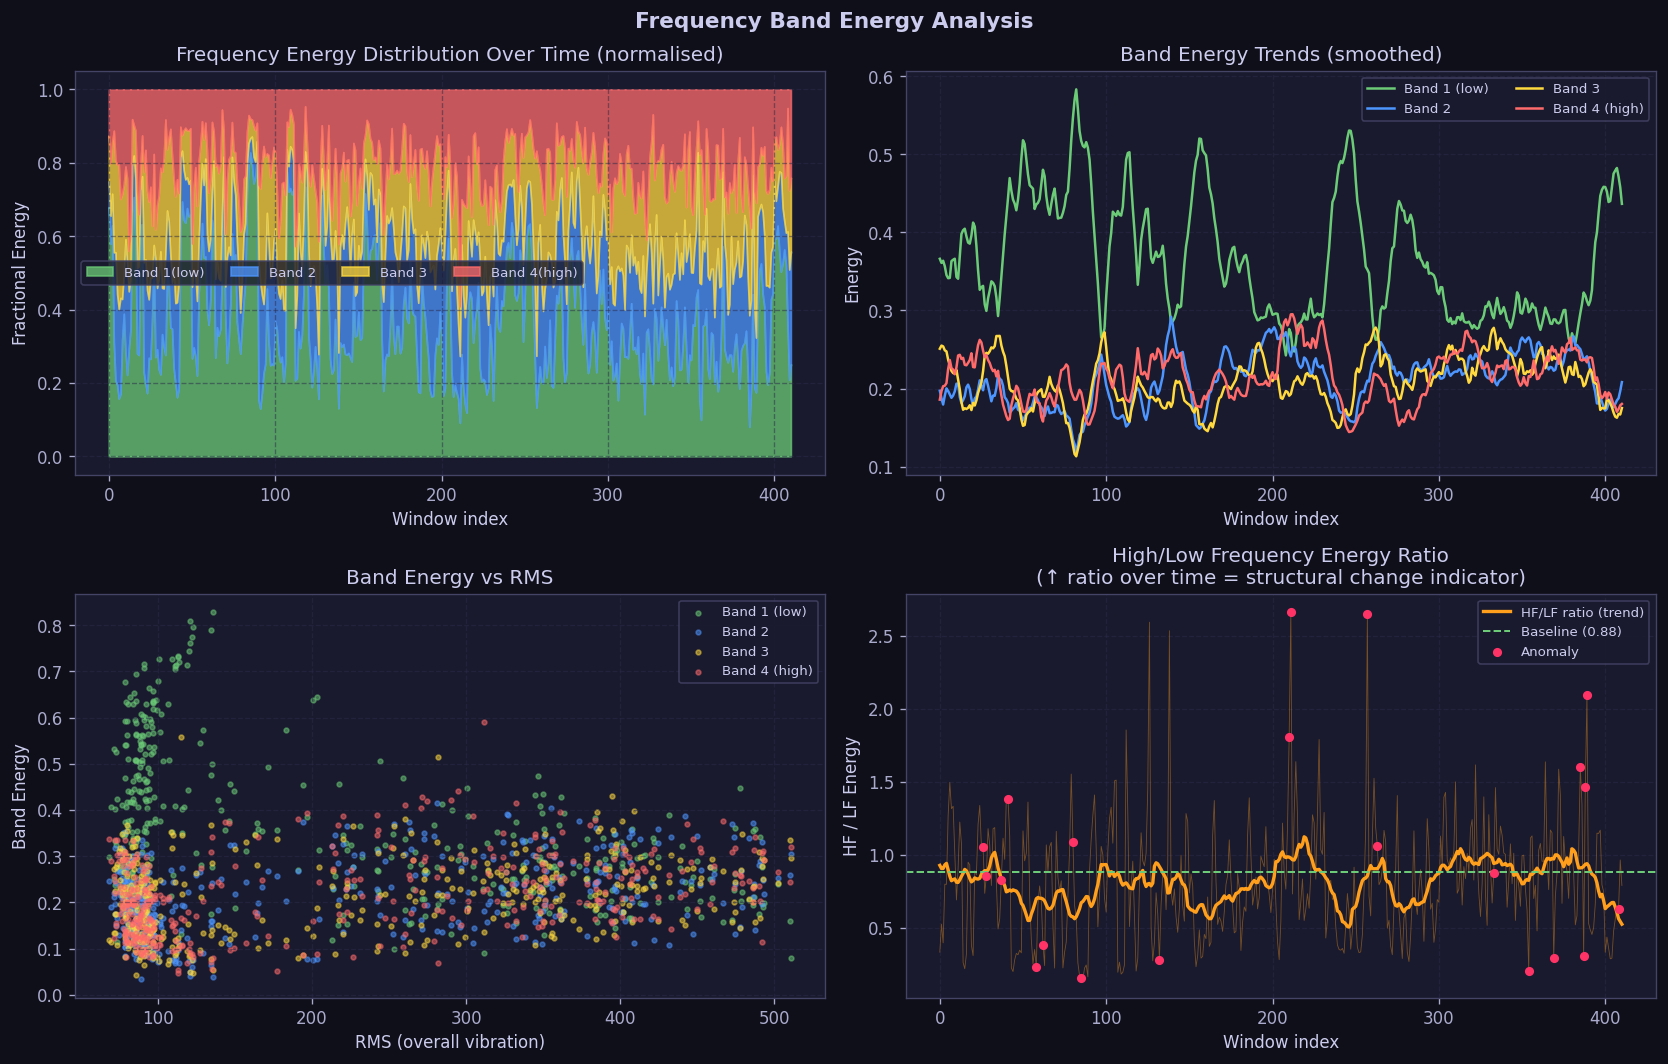

In [31]:
band_cols  = ['Band1_Energy','Band2_Energy','Band3_Energy','Band4_Energy']
band_labels = ['Band 1\n(low)','Band 2','Band 3','Band 4\n(high)']
band_colors = ['#6bcb77','#4d96ff','#ffd93d','#ff6b6b']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Frequency Band Energy Analysis', fontsize=13, fontweight='bold')

# Stacked area — energy distribution over time
ax = axes[0, 0]
band_data = df[band_cols].values
band_norm  = band_data / (band_data.sum(axis=1, keepdims=True) + 1e-9)
bottom = np.zeros(len(df))
for i, (col, label, color) in enumerate(zip(band_cols, band_labels, band_colors)):
    ax.fill_between(t, bottom, bottom + band_norm[:, i],
                    label=label.replace('\n',''), color=color, alpha=0.75)
    bottom += band_norm[:, i]
ax.set_title('Frequency Energy Distribution Over Time (normalised)')
ax.set_xlabel('Window index')
ax.set_ylabel('Fractional Energy')
ax.legend(ncol=4, fontsize=8)
ax.grid(True)

# Raw band energy over time
ax2 = axes[0, 1]
for col, label, color in zip(band_cols, band_labels, band_colors):
    smooth = df[col].rolling(15, center=True, min_periods=1).mean()
    ax2.plot(t, smooth, color=color, lw=1.5, label=label.replace('\n',' '))
ax2.set_title('Band Energy Trends (smoothed)')
ax2.set_xlabel('Window index')
ax2.set_ylabel('Energy')
ax2.legend(ncol=2, fontsize=8)
ax2.grid(True)

# Band correlation with RMS
ax3 = axes[1, 0]
for col, label, color in zip(band_cols, band_labels, band_colors):
    ax3.scatter(df['RMS'], df[col], color=color, s=8, alpha=0.5, label=label.replace('\n',' '))
ax3.set_xlabel('RMS (overall vibration)')
ax3.set_ylabel('Band Energy')
ax3.set_title('Band Energy vs RMS')
ax3.legend(fontsize=8)
ax3.grid(True)

# High-to-low frequency ratio (damage indicator)
ax4 = axes[1, 1]
df['hf_lf_ratio'] = (df['Band3_Energy'] + df['Band4_Energy']) / (df['Band1_Energy'] + df['Band2_Energy'] + 1e-9)
ratio_smooth = df['hf_lf_ratio'].rolling(20, center=True, min_periods=1).mean()
ax4.plot(t, df['hf_lf_ratio'], color='#ff9f1c', lw=0.5, alpha=0.4)
ax4.plot(t, ratio_smooth, color='#ff9f1c', lw=2, label='HF/LF ratio (trend)')
baseline_ratio = df['hf_lf_ratio'].iloc[:int(len(df)*0.1)].mean()
ax4.axhline(baseline_ratio, color='#6bcb77', lw=1.2, linestyle='--',
            label=f'Baseline ({baseline_ratio:.2f})')
ax4.scatter(t[anom_m], df.loc[anom_m,'hf_lf_ratio'], color='#ff3366', s=20, zorder=5, label='Anomaly')
ax4.set_title('High/Low Frequency Energy Ratio\n(↑ ratio over time = structural change indicator)')
ax4.set_xlabel('Window index')
ax4.set_ylabel('HF / LF Energy')
ax4.legend(fontsize=8)
ax4.grid(True)

plt.tight_layout()
plt.savefig('13_frequency_bands.png', bbox_inches='tight', dpi=130)
plt.show()

## 14. Summary Dashboard

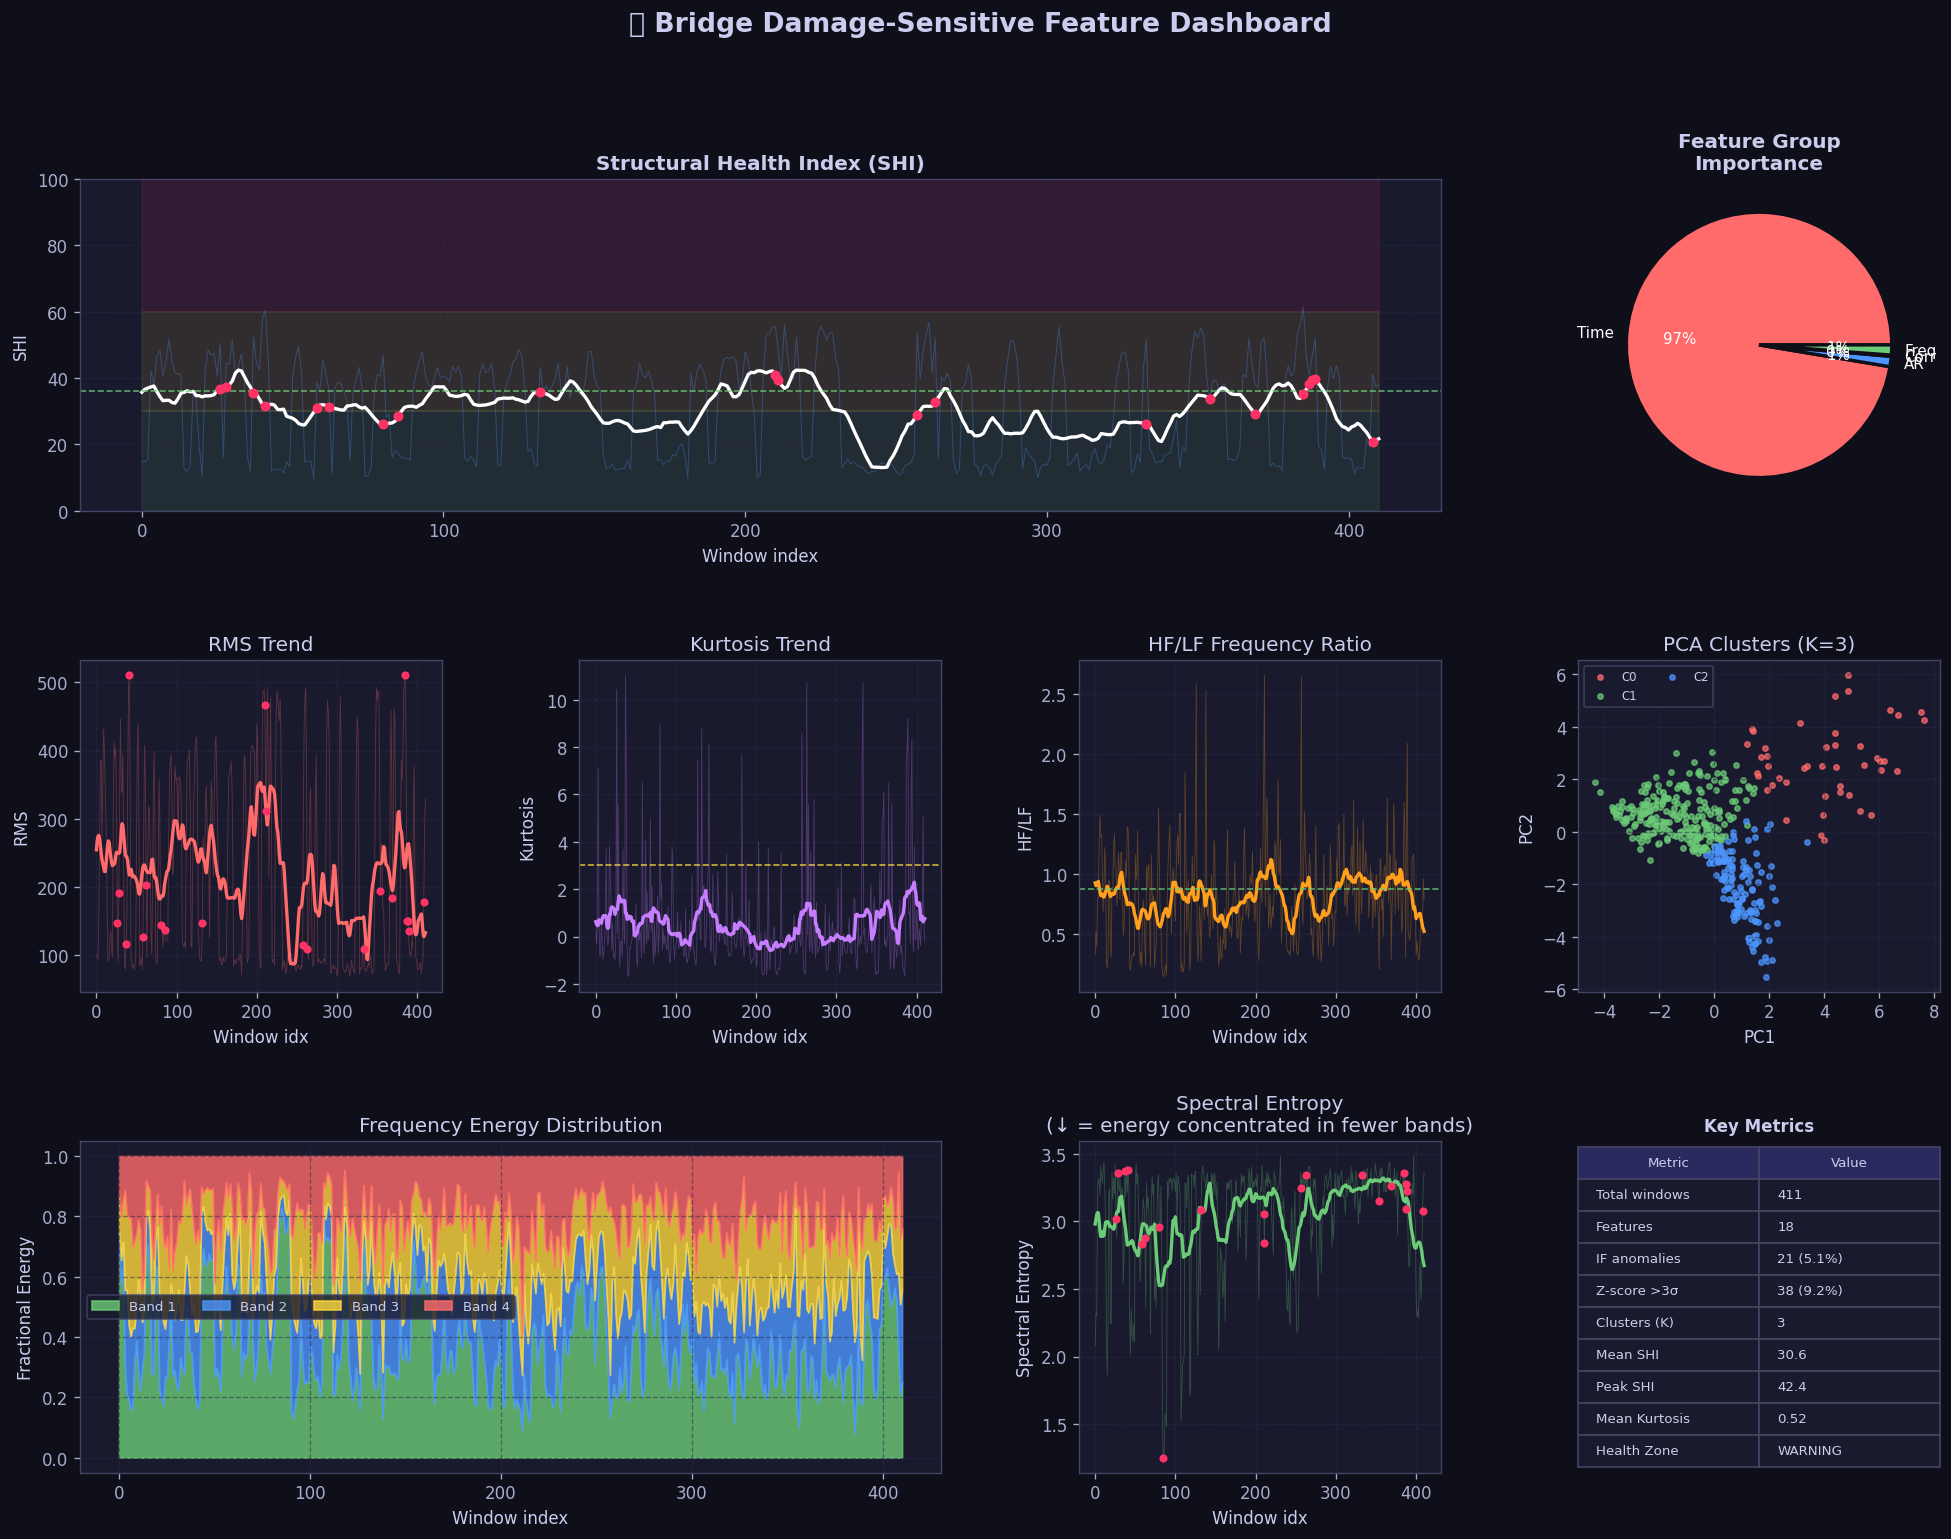

✅ Dashboard saved.


In [32]:
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle('🌉 Bridge Damage-Sensitive Feature Dashboard', fontsize=16, fontweight='bold')

# ── Row 1: SHI (wide) + Anomaly score ─────────────────────────────────────────
ax_shi = fig.add_subplot(gs[0, :3])
ax_shi.fill_between(t, 0, 30, alpha=0.10, color='#6bcb77')
ax_shi.fill_between(t, 30, 60, alpha=0.10, color='#ffd93d')
ax_shi.fill_between(t, 60, 100,alpha=0.10, color='#ff3366')
ax_shi.plot(t, df['SHI'], color='#4d96ff', lw=0.6, alpha=0.3)
ax_shi.plot(t, df['SHI_smooth'], color='white', lw=2)
ax_shi.scatter(t[anom_m], df.loc[anom_m,'SHI_smooth'], color='#ff3366', s=25, zorder=5)
ax_shi.axhline(baseline_shi, color='#6bcb77', lw=1, linestyle='--', alpha=0.8)
ax_shi.set_ylim(0, 100)
ax_shi.set_title('Structural Health Index (SHI)', fontweight='bold')
ax_shi.set_ylabel('SHI')
ax_shi.set_xlabel('Window index')
ax_shi.grid(True)

# ── Pie chart ──────────────────────────────────────────────────────────────────
ax_pie = fig.add_subplot(gs[0, 3])
group_imp_vals = list(group_imp.values())
ax_pie.pie(group_imp_vals, labels=list(GROUP_COLORS.keys()),
           colors=list(GROUP_COLORS.values()), autopct='%1.0f%%',
           textprops={'color':'white','fontsize':9},
           wedgeprops={'edgecolor':'#0f0f1a','linewidth':2})
ax_pie.set_title('Feature Group\nImportance', fontweight='bold')

# ── Row 2: RMS trend | Kurtosis | HF/LF ratio | PCA ─────────────────────────
ax_rms = fig.add_subplot(gs[1, 0])
smooth_rms = df['RMS'].rolling(20, center=True, min_periods=1).mean()
ax_rms.plot(t, df['RMS'], color='#ff6b6b', lw=0.5, alpha=0.3)
ax_rms.plot(t, smooth_rms, color='#ff6b6b', lw=2)
ax_rms.scatter(t[anom_m], df.loc[anom_m,'RMS'], color='#ff3366', s=15, zorder=5)
ax_rms.set_title('RMS Trend')
ax_rms.set_ylabel('RMS')
ax_rms.set_xlabel('Window idx')
ax_rms.grid(True)

ax_kurt = fig.add_subplot(gs[1, 1])
smooth_k = df['Kurtosis'].rolling(20, center=True, min_periods=1).mean()
ax_kurt.plot(t, df['Kurtosis'], color='#c77dff', lw=0.5, alpha=0.3)
ax_kurt.plot(t, smooth_k, color='#c77dff', lw=2)
ax_kurt.axhline(3, color='#ffd93d', lw=1, linestyle='--', alpha=0.8)
ax_kurt.set_title('Kurtosis Trend')
ax_kurt.set_ylabel('Kurtosis')
ax_kurt.set_xlabel('Window idx')
ax_kurt.grid(True)

ax_hflf = fig.add_subplot(gs[1, 2])
ax_hflf.plot(t, df['hf_lf_ratio'], color='#ff9f1c', lw=0.5, alpha=0.3)
ax_hflf.plot(t, ratio_smooth, color='#ff9f1c', lw=2)
ax_hflf.axhline(baseline_ratio, color='#6bcb77', lw=1, linestyle='--', alpha=0.8)
ax_hflf.set_title('HF/LF Frequency Ratio')
ax_hflf.set_ylabel('HF/LF')
ax_hflf.set_xlabel('Window idx')
ax_hflf.grid(True)

ax_pca2 = fig.add_subplot(gs[1, 3])
for k in range(best_k):
    mask = df['cluster'] == k
    ax_pca2.scatter(X_pca[mask,0], X_pca[mask,1],
                    color=CLUSTER_COLORS[k], s=10, alpha=0.7, label=f'C{k}')
ax_pca2.set_title(f'PCA Clusters (K={best_k})')
ax_pca2.set_xlabel('PC1')
ax_pca2.set_ylabel('PC2')
ax_pca2.legend(fontsize=7, ncol=2)
ax_pca2.grid(True)

# ── Row 3: Stacked bands | Spectral Entropy | Stats table ─────────────────────
ax_bands = fig.add_subplot(gs[2, :2])
bottom2 = np.zeros(len(df))
for i, (col, color) in enumerate(zip(band_cols, band_colors)):
    ax_bands.fill_between(t, bottom2, bottom2 + band_norm[:,i],
                          color=color, alpha=0.8, label=f'Band {i+1}')
    bottom2 += band_norm[:,i]
ax_bands.set_title('Frequency Energy Distribution')
ax_bands.set_xlabel('Window index')
ax_bands.set_ylabel('Fractional Energy')
ax_bands.legend(ncol=4, fontsize=8)
ax_bands.grid(True)

ax_se = fig.add_subplot(gs[2, 2])
smooth_se = df['Spectral_Entropy'].rolling(20, center=True, min_periods=1).mean()
ax_se.plot(t, df['Spectral_Entropy'], color='#6bcb77', lw=0.5, alpha=0.3)
ax_se.plot(t, smooth_se, color='#6bcb77', lw=2)
ax_se.scatter(t[anom_m], df.loc[anom_m,'Spectral_Entropy'], color='#ff3366', s=15, zorder=5)
ax_se.set_title('Spectral Entropy\n(↓ = energy concentrated in fewer bands)')
ax_se.set_ylabel('Spectral Entropy')
ax_se.set_xlabel('Window idx')
ax_se.grid(True)

# Stats table
ax_tbl = fig.add_subplot(gs[2, 3])
ax_tbl.axis('off')
stats_data = [
    ['Metric', 'Value'],
    ['Total windows', str(len(df))],
    ['Features', str(len(ALL_FEATS))],
    ['IF anomalies', f'{n_iso} ({n_iso/len(df)*100:.1f}%)'],
    ['Z-score >3σ', f'{n_z} ({n_z/len(df)*100:.1f}%)'],
    ['Clusters (K)', str(best_k)],
    ['Mean SHI', f'{df["SHI_smooth"].mean():.1f}'],
    ['Peak SHI', f'{df["SHI_smooth"].max():.1f}'],
    ['Mean Kurtosis', f'{df["Kurtosis"].mean():.2f}'],
    ['Health Zone', zone],
]
tbl = ax_tbl.table(cellText=stats_data[1:], colLabels=stats_data[0],
                    loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.6)
for (r,c), cell in tbl.get_celld().items():
    cell.set_facecolor('#1a1a2e' if r>0 else '#2a2a5e')
    cell.set_edgecolor('#444466')
    cell.set_text_props(color='#ccccee')
ax_tbl.set_title('Key Metrics', fontsize=10, fontweight='bold')

plt.savefig('14_dashboard.png', bbox_inches='tight', dpi=140)
plt.show()
print('✅ Dashboard saved.')

## 15. Interpretation Guide

| Feature | What it means for your bridge |
|---|---|
| **RMS / Std** | Overall vibration energy. Rising trend = more stress or looser structure. |
| **Kurtosis** | >3 = impulsive/sharp hits, <0 = very flat/uniform. Sudden spikes = cracks or loose joints. |
| **Crest Factor** | Peak / RMS. High = rare but extreme spikes — impact events. |
| **Shape Factor** | RMS / Mean. Sensitive to waveform shape change. |
| **AR1, AR2** | Autoregressive model coefficients — capture temporal memory. Change = dynamics altered. |
| **AR_Residual_Std** | Prediction error of AR model. **High = the system behaves unpredictably = stress.** |
| **Corr_XZ / Corr_YZ** | Cross-axis coupling. Normally low — rising = torsional/asymmetric deformation. |
| **Band1–4 Energy** | Energy in frequency sub-bands. Shift from low→high bands = stiffness loss (natural frequency drop). |
| **Spectral Centroid** | Weighted centre of frequency spectrum. Drops when bridge softens. |
| **Spectral Entropy** | Spread of energy across bands. Low = concentrated (resonance). High = broadband (noise/damage). |
| **HF/LF Ratio** | Custom index. **Rising over time = energy shifting to higher bands = structural stiffness change.** |
| **SHI** | Composite 0–100 score: <30 healthy, 30–60 monitor, 60–100 critical. |

### 🔑 Key SHM Principle
The most powerful use of this data is **comparing multiple recordings over time** (e.g., weekly tests).  
A rising SHI trend, dropping Spectral Centroid, or shifting HF/LF ratio across sessions is a reliable early damage indicator — even before visible cracking appears.